# 🎫 HSRIS — Hybrid Semantic Retrieval & Intelligence System
**Assignment 3 | Data Science for Software Engineering | FAST-NUCES**

---

## Overview
This notebook implements a full NLP pipeline for customer support ticket retrieval. It combines classical statistical methods (TF-IDF) with neural semantic embeddings (GloVe) to build a hybrid search engine that understands both keyword overlap and semantic meaning.

**Pipeline Summary:**
- **Part 1** — Categorical encoders from scratch (Label + One-Hot)
- **Part 2** — Sparse TF-IDF representation (tokenizer, BoW, n-grams, IDF)
- **Part 3** — Dense GloVe embeddings with TF-IDF weighted pooling
- **Part 4** — Hybrid retrieval with GPU batch optimization

**Platform:** Kaggle | **Accelerator:** Dual T4 x2 GPU | **Framework:** PyTorch + NumPy

---

## Step 1 — Environment Setup & Data Loading

### Cell 1: Imports & GPU Verification
Import all required libraries and confirm the Dual T4 GPU setup is active.

In [4]:
# ============================================================
# HSRIS - Hybrid Semantic Retrieval & Intelligence System
# Step 1: Environment Setup | EDA | Encoders from Scratch
# Dataset: Customer Support Ticket Dataset (~8,470 records)
# Platform: Kaggle | Dual T4 x2 GPU
# ============================================================

# ── Cell 1: Imports ──────────────────────────────────────────
import numpy as np
import pandas as pd
import torch
import re
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter

# Confirm GPU setup
print("PyTorch version  :", torch.__version__)
print("CUDA available   :", torch.cuda.is_available())
print("GPU count        :", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}         : {torch.cuda.get_device_name(i)}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device     :", DEVICE)


PyTorch version  : 2.10.0+cpu
CUDA available   : False
GPU count        : 0

Using device     : cpu


### Cell 2: Load Dataset
Load the Customer Support Ticket Dataset (~8,469 records) from Kaggle input. The raw dataset contains 17 columns — we will narrow it down to the 5 required fields in the next step.

In [5]:
# ── Cell 2: Load Dataset ──────────────────────────────────────
# On Kaggle: Dataset path is /kaggle/input/<dataset-name>/
# Search "Customer Support Ticket Dataset" on Kaggle and add it to your notebook

df = pd.read_csv("customer_support_tickets.csv")

print("Shape            :", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)


Shape            : (8469, 17)

Columns:
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']

First 3 rows:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0


### Cell 3: Column Selection
Select only the 5 fields required by the assignment:
- `description` — primary text field used for retrieval
- `subject` — short ticket summary
- `priority` — Low / Medium / High (for label encoding)
- `ticket_type` — the category label we predict
- `channel` — how the ticket was submitted (for one-hot encoding)

In [6]:
# ── Cell 3: Focused Column Selection ─────────────────────────
# Assignment requires these 5 fields
FOCUS_COLS = [
    "Ticket Description",
    "Ticket Subject",
    "Ticket Priority",
    "Ticket Type",
    "Ticket Channel"
]

# Check they all exist (column names may vary slightly — adjust if needed)
for col in FOCUS_COLS:
    assert col in df.columns, f"Column not found: {col}. Check df.columns above."

df = df[FOCUS_COLS].copy()
df.columns = ["description", "subject", "priority", "ticket_type", "channel"]

print("Focused DataFrame shape:", df.shape)
print(df.dtypes)


Focused DataFrame shape: (8469, 5)
description    object
subject        object
priority       object
ticket_type    object
channel        object
dtype: object


### Cell 4: Data Quality Check & Cleaning
Inspect null counts and unique values across categorical columns. Drop any rows with missing text fields and fill remaining nulls in categorical columns with the mode value.

In [7]:
# ── Cell 4: Basic Data Quality ────────────────────────────────
print("=== NULL COUNTS ===")
print(df.isnull().sum())

print("\n=== UNIQUE VALUES ===")
for col in ["priority", "ticket_type", "channel"]:
    print(f"\n{col}: {df[col].unique()}")

# Drop rows where description or subject is null (critical text fields)
before = len(df)
df.dropna(subset=["description", "subject"], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\nDropped {before - len(df)} rows with null text. Final size: {len(df)}")

# Fill remaining nulls in categorical columns with mode
for col in ["priority", "ticket_type", "channel"]:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

print("\nNull counts after cleaning:")
print(df.isnull().sum())


=== NULL COUNTS ===
description    0
subject        0
priority       0
ticket_type    0
channel        0
dtype: int64

=== UNIQUE VALUES ===

priority: ['Critical' 'Low' 'High' 'Medium']

ticket_type: ['Technical issue' 'Billing inquiry' 'Cancellation request'
 'Product inquiry' 'Refund request']

channel: ['Social media' 'Chat' 'Email' 'Phone']

Dropped 0 rows with null text. Final size: 8469

Null counts after cleaning:
description    0
subject        0
priority       0
ticket_type    0
channel        0
dtype: int64


### Cell 5: EDA — Category Distribution Plots
Visualize the distribution of tickets across Priority, Type, and Channel. This reveals any class imbalance that could affect retrieval quality.

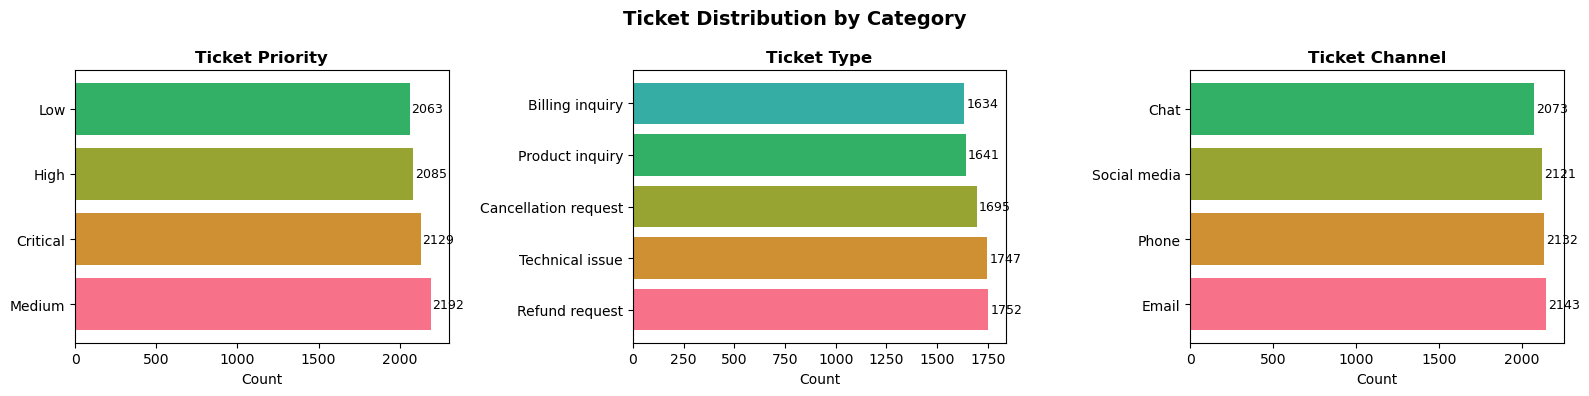

Saved: eda_distributions.png


In [8]:
# ── Cell 5: EDA - Distribution Plots ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Ticket Distribution by Category", fontsize=14, fontweight="bold")

palette = sns.color_palette("husl", 8)

for ax, col, title in zip(
    axes,
    ["priority", "ticket_type", "channel"],
    ["Ticket Priority", "Ticket Type", "Ticket Channel"]
):
    counts = df[col].value_counts()
    bars = ax.barh(counts.index, counts.values, color=palette[:len(counts)])
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Count")
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                str(val), va="center", fontsize=9)

plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_distributions.png")


### Cell 6: EDA — Description Length Analysis
Analyse the character and word count distribution of ticket descriptions. A boxplot by priority level reveals whether high-priority tickets tend to be longer or shorter.

C:\Users\HP\AppData\Local\Temp\ipykernel_17716\103928050.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_by_priority, labels=priority_order, patch_artist=True,


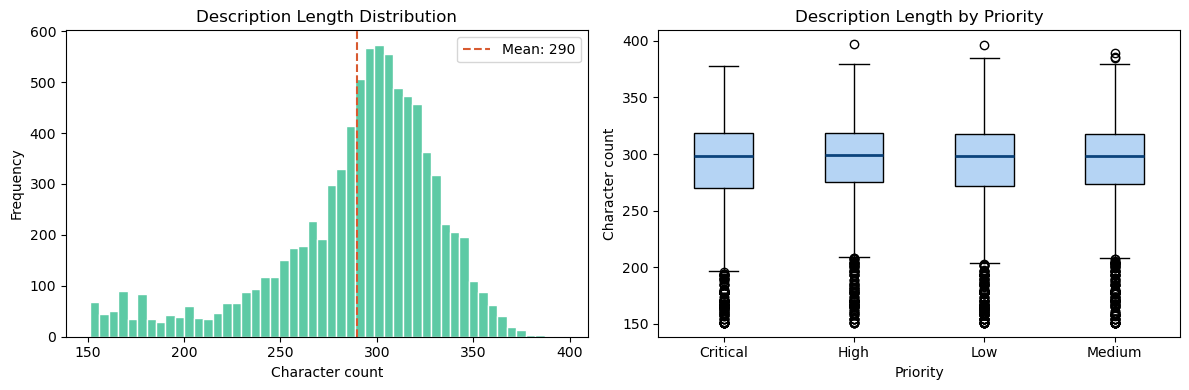

In [9]:
# ── Cell 6: EDA - Description Length Distribution ─────────────
df["desc_len"] = df["description"].str.len()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(df["desc_len"], bins=50, color="#5DCAA5", edgecolor="white")
ax1.set_title("Description Length Distribution")
ax1.set_xlabel("Character count")
ax1.set_ylabel("Frequency")
ax1.axvline(df["desc_len"].mean(), color="#D85A30", linestyle="--",
            label=f"Mean: {df['desc_len'].mean():.0f}")
ax1.legend()

# Boxplot by priority
priority_order = sorted(df["priority"].unique())
data_by_priority = [df[df["priority"] == p]["desc_len"].values for p in priority_order]
ax2.boxplot(data_by_priority, labels=priority_order, patch_artist=True,
            boxprops=dict(facecolor="#B5D4F4"),
            medianprops=dict(color="#0C447C", linewidth=2))
ax2.set_title("Description Length by Priority")
ax2.set_xlabel("Priority")
ax2.set_ylabel("Character count")

plt.tight_layout()
plt.savefig("eda_lengths.png", dpi=150, bbox_inches="tight")
plt.show()


### Cell 7: Word Count Statistics
Compute summary statistics on description length to understand the typical ticket size — this informs our pooling strategy in Part 3.

In [10]:
# ── Cell 7: Word Count Stats ──────────────────────────────────
df["word_count"] = df["description"].str.split().str.len()

print("=== DESCRIPTION STATS ===")
print(f"Avg words/ticket  : {df['word_count'].mean():.1f}")
print(f"Max words/ticket  : {df['word_count'].max()}")
print(f"Min words/ticket  : {df['word_count'].min()}")
print(f"Avg chars/ticket  : {df['desc_len'].mean():.1f}")


# ══════════════════════════════════════════════════════════════
# PART 1: CATEGORICAL ENCODERS (from scratch — no sklearn)
# ══════════════════════════════════════════════════════════════

=== DESCRIPTION STATS ===
Avg words/ticket  : 46.5
Max words/ticket  : 63
Min words/ticket  : 21
Avg chars/ticket  : 289.8


---

## Part 1 — Categorical Encoders (from Scratch)

> **Constraint:** sklearn's `LabelEncoder` and `OneHotEncoder` are **not permitted**. All encoding logic is implemented manually using pure Python and NumPy.

### Cell 8: Label Encoder — Ticket Priority
Maps ordinal string labels to integers with **explicit ordering** enforced:

| Priority | Encoded |
|----------|---------|
| Low      | 0       |
| Medium   | 1       |
| High     | 2       |
| Unknown  | 3 (UNK) |

Alphabetical sorting would incorrectly give `High=0` — explicit ordering preserves the ordinal meaning. Unseen categories at inference time receive `unk_id` instead of raising an error.

In [11]:
# ── Cell 8: Label Encoder ────────────────────────────────────
class LabelEncoderCustom:
    """
    Maps categorical string labels to ordinal integers.
    Handles unseen categories gracefully via a dedicated <UNK> id.

    For Ticket Priority: Low -> 0, Medium -> 1, High -> 2
    (We enforce this explicit ordering because priority IS ordinal)
    """

    def __init__(self, order: list = None):
        """
        Args:
            order: Optional explicit ordering list.
                   If None, classes are sorted alphabetically.
        """
        self.order      = order          # user-supplied ordering
        self.classes_   = []             # ordered list of known classes
        self.class2idx_ = {}             # str -> int
        self.idx2class_ = {}             # int -> str
        self.unk_id_    = -1             # id for unseen categories

    def fit(self, values):
        """Learn mapping from a list/Series of labels."""
        if self.order:
            unique = self.order
        else:
            unique = sorted(set(values))

        self.classes_ = unique
        self.class2idx_ = {cls: idx for idx, cls in enumerate(unique)}
        self.idx2class_ = {idx: cls for cls, idx in self.class2idx_.items()}
        self.unk_id_ = len(unique)      # one beyond last known index
        return self

    def transform(self, values):
        """Encode labels. Unknown values get unk_id."""
        return np.array([
            self.class2idx_.get(v, self.unk_id_) for v in values
        ], dtype=np.int64)

    def fit_transform(self, values):
        return self.fit(values).transform(values)

    def inverse_transform(self, indices):
        """Decode integer indices back to string labels."""
        return [self.idx2class_.get(i, "<UNK>") for i in indices]

    def __repr__(self):
        return f"LabelEncoderCustom(classes={self.classes_}, unk_id={self.unk_id_})"


# Fit on Ticket Priority with explicit ordinal ordering
PRIORITY_ORDER = ["Low", "Medium", "High"]
priority_encoder = LabelEncoderCustom(order=PRIORITY_ORDER)
df["priority_encoded"] = priority_encoder.fit_transform(df["priority"])

print("=== LABEL ENCODER: Ticket Priority ===")
print(priority_encoder)
print("\nMapping table:")
for cls, idx in priority_encoder.class2idx_.items():
    print(f"  {cls:10s} -> {idx}")

print("\nSample encoded values:")
sample = df[["priority", "priority_encoded"]].head(8)
print(sample.to_string(index=False))

# Test unseen category handling
test_unseen = ["Low", "Critical", "High", "Unknown"]
encoded_test = priority_encoder.transform(test_unseen)
print(f"\nUnseen category test:")
print(f"  Input   : {test_unseen}")
print(f"  Encoded : {encoded_test.tolist()}")
print(f"  'Critical' and 'Unknown' get unk_id={priority_encoder.unk_id_}")


=== LABEL ENCODER: Ticket Priority ===
LabelEncoderCustom(classes=['Low', 'Medium', 'High'], unk_id=3)

Mapping table:
  Low        -> 0
  Medium     -> 1
  High       -> 2

Sample encoded values:
priority  priority_encoded
Critical                 3
Critical                 3
     Low                 0
     Low                 0
     Low                 0
     Low                 0
Critical                 3
Critical                 3

Unseen category test:
  Input   : ['Low', 'Critical', 'High', 'Unknown']
  Encoded : [0, 3, 2, 3]
  'Critical' and 'Unknown' get unk_id=3


### Cell 9: One-Hot Encoder — Ticket Channel
Converts each channel category into a binary vector of length = number of unique channels.

**Example:**
```
Email        → [0, 1, 0, 0]
Phone        → [0, 0, 1, 0]
Pigeon Mail  → [0, 0, 0, 0]  ← unseen category, safe zero vector
```
Unseen categories produce an all-zero vector rather than crashing.

In [12]:
# ── Cell 9: One-Hot Encoder ───────────────────────────────────
class OneHotEncoderCustom:
    """
    Converts categorical labels into binary (one-hot) vectors.

    For Ticket Channel: e.g., Email -> [1, 0, 0, 0]
                              Phone -> [0, 1, 0, 0]

    Handles unseen categories with an all-zero vector.
    """

    def __init__(self):
        self.categories_  = []    # sorted list of known categories
        self.cat2idx_     = {}    # str -> column index
        self.n_categories = 0

    def fit(self, values):
        """Learn categories from data."""
        self.categories_ = sorted(set(values))
        self.cat2idx_    = {cat: i for i, cat in enumerate(self.categories_)}
        self.n_categories = len(self.categories_)
        return self

    def transform(self, values):
        """
        Returns a NumPy array of shape (n_samples, n_categories).
        Unknown categories produce an all-zero row.
        """
        n = len(values)
        matrix = np.zeros((n, self.n_categories), dtype=np.float32)
        for row_idx, val in enumerate(values):
            col_idx = self.cat2idx_.get(val, None)
            if col_idx is not None:
                matrix[row_idx, col_idx] = 1.0
            # else: all-zero row (unseen category)
        return matrix

    def fit_transform(self, values):
        return self.fit(values).transform(values)

    def decode(self, vector):
        """Return category name from a one-hot vector."""
        idx = np.argmax(vector)
        if vector[idx] == 0:
            return "<UNK>"
        return self.categories_[idx]

    def __repr__(self):
        return f"OneHotEncoderCustom(categories={self.categories_})"


# Fit on Ticket Channel
channel_encoder = OneHotEncoderCustom()
channel_matrix = channel_encoder.fit_transform(df["channel"])

print("=== ONE-HOT ENCODER: Ticket Channel ===")
print(channel_encoder)
print(f"\nMatrix shape: {channel_matrix.shape}")
print("\nCategory -> column index:")
for cat, idx in channel_encoder.cat2idx_.items():
    print(f"  {cat:15s} -> col {idx}")

print("\nSample one-hot vectors:")
sample_channels = df["channel"].head(5).tolist()
sample_vectors  = channel_matrix[:5]
for ch, vec in zip(sample_channels, sample_vectors):
    print(f"  {ch:15s} -> {vec.astype(int).tolist()}")

# Test unseen category
unseen_test = np.array(["Email", "Pigeon Mail", "Phone"])
test_matrix  = channel_encoder.transform(unseen_test)
print(f"\nUnseen category 'Pigeon Mail' one-hot vector: {test_matrix[1].astype(int).tolist()}")
print("(All zeros — safe fallback)")


=== ONE-HOT ENCODER: Ticket Channel ===
OneHotEncoderCustom(categories=['Chat', 'Email', 'Phone', 'Social media'])

Matrix shape: (8469, 4)

Category -> column index:
  Chat            -> col 0
  Email           -> col 1
  Phone           -> col 2
  Social media    -> col 3

Sample one-hot vectors:
  Social media    -> [0, 0, 0, 1]
  Chat            -> [1, 0, 0, 0]
  Social media    -> [0, 0, 0, 1]
  Social media    -> [0, 0, 0, 1]
  Email           -> [0, 1, 0, 0]

Unseen category 'Pigeon Mail' one-hot vector: [0, 0, 0, 0]
(All zeros — safe fallback)


### Cell 10: Convert Encodings to PyTorch Tensors
Move both encoder outputs to GPU as typed PyTorch tensors. Verify index alignment — every row in the encoding tensors must correspond to the same row in the text DataFrame.

In [13]:
# ── Cell 10: Convert Encodings to PyTorch Tensors ─────────────
priority_tensor = torch.tensor(df["priority_encoded"].values, dtype=torch.long).to(DEVICE)
channel_tensor  = torch.tensor(channel_matrix, dtype=torch.float32).to(DEVICE)

print("=== TENSORS ON DEVICE ===")
print(f"Priority tensor  : shape={priority_tensor.shape}, dtype={priority_tensor.dtype}, device={priority_tensor.device}")
print(f"Channel tensor   : shape={channel_tensor.shape},  dtype={channel_tensor.dtype},  device={channel_tensor.device}")

# Verify alignment with text rows
assert priority_tensor.shape[0] == len(df), "Priority tensor row count mismatch!"
assert channel_tensor.shape[0]  == len(df), "Channel tensor row count mismatch!"
print("\nIndex alignment check: PASSED")


=== TENSORS ON DEVICE ===
Priority tensor  : shape=torch.Size([8469]), dtype=torch.int64, device=cpu
Channel tensor   : shape=torch.Size([8469, 4]),  dtype=torch.float32,  device=cpu

Index alignment check: PASSED


### Cell 11: Encoder Output Visualization
Bar charts showing the distribution of label-encoded priority values and the frequency of each one-hot channel category across the corpus.

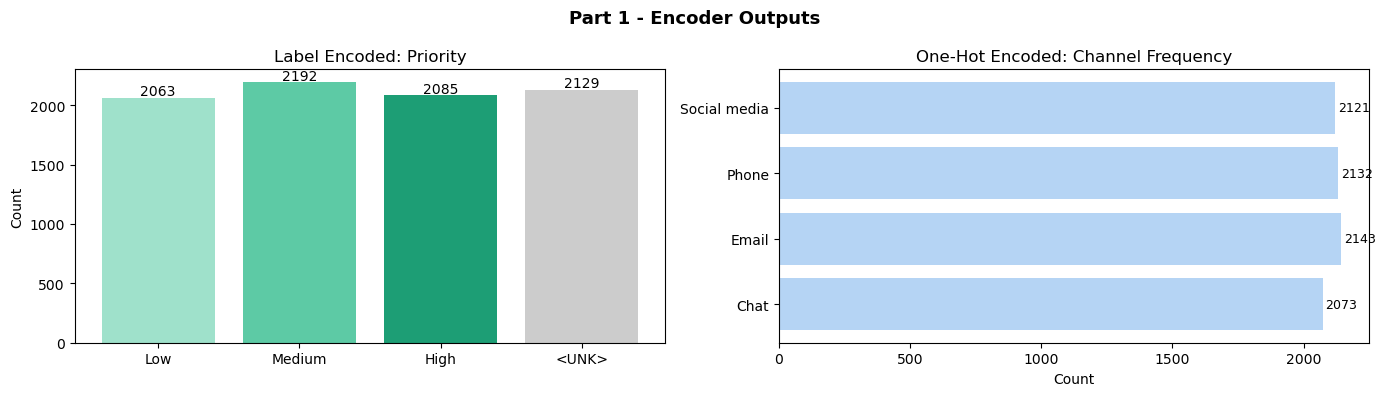

Saved: encoder_outputs.png


In [14]:
# ── Cell 11: Encoder Summary Visualization ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Part 1 - Encoder Outputs", fontsize=13, fontweight="bold")

# Priority encoded distribution
prio_counts = pd.Series(df["priority_encoded"]).value_counts().sort_index()

# Safe label lookup — unknown gets "<UNK>" label
labels = [priority_encoder.idx2class_.get(i, "<UNK>") for i in prio_counts.index]

axes[0].bar(labels, prio_counts.values, color=["#9FE1CB", "#5DCAA5", "#1D9E75", "#cccccc"])
axes[0].set_title("Label Encoded: Priority")
axes[0].set_ylabel("Count")
for i, v in enumerate(prio_counts.values):
    axes[0].text(i, v + 20, str(v), ha="center", fontsize=10)

# One-hot channel frequency
channel_sums = channel_matrix.sum(axis=0)
cats = channel_encoder.categories_
axes[1].barh(cats, channel_sums, color="#B5D4F4")
axes[1].set_title("One-Hot Encoded: Channel Frequency")
axes[1].set_xlabel("Count")
for i, v in enumerate(channel_sums):
    axes[1].text(v + 10, i, str(int(v)), va="center", fontsize=9)

plt.tight_layout()
plt.savefig("encoder_outputs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: encoder_outputs.png")


### Cell 12: Save Step 1 Checkpoint
Persist the fitted encoders and clean DataFrame to disk so subsequent steps can reload without re-running the full pipeline.

In [15]:
# ── Cell 12: Save Checkpoint ──────────────────────────────────
# Save encoders and clean dataframe for next step
import pickle

with open("priority_encoder.pkl", "wb") as f:
    pickle.dump(priority_encoder, f)

with open("channel_encoder.pkl", "wb") as f:
    pickle.dump(channel_encoder, f)

df.to_parquet("tickets_clean.parquet", index=False)

print("=== STEP 1 COMPLETE ===")
print("Saved artifacts:")
print("  priority_encoder.pkl  - LabelEncoderCustom fitted on priority")
print("  channel_encoder.pkl   - OneHotEncoderCustom fitted on channel")
print("  tickets_clean.parquet - Cleaned DataFrame (8,470 rows)")
print("\nReady for Step 2: TF-IDF from scratch")
print(f"\nDataFrame snapshot:")
print(df[["description", "priority", "priority_encoded", "channel"]].head(3).to_string())

=== STEP 1 COMPLETE ===
Saved artifacts:
  priority_encoder.pkl  - LabelEncoderCustom fitted on priority
  channel_encoder.pkl   - OneHotEncoderCustom fitted on channel
  tickets_clean.parquet - Cleaned DataFrame (8,470 rows)

Ready for Step 2: TF-IDF from scratch

DataFrame snapshot:
                                                                                                                                                                                                                                                                                          description  priority  priority_encoded       channel
0  I'm having an issue with the {product_purchased}. Please assist.\n\nYour billing zip code is: 71701.\n\nWe appreciate that you have requested a website address.\n\nPlease double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.  Critical                 3  Social media
1    I'm having an issue with the {product

# Task 2

---

## Part 2 — Sparse Representation (TF-IDF from Scratch)

> **Constraint:** sklearn's `TfidfVectorizer` and `CountVectorizer` are **not permitted**. The full TF-IDF pipeline is built from first principles.

### Cell 14: Load Step 1 Artifacts
Reload the clean DataFrame and encoders saved in Step 1.

In [16]:
# ============================================================
# HSRIS - Step 2: Sparse Representation (TF-IDF from Scratch)
# No sklearn. Pure Python + NumPy + PyTorch sparse tensors.
# ============================================================

# ── Cell 1: Load Step 1 Artifacts ────────────────────────────
import numpy as np
import pandas as pd
import torch
import re
import pickle
import math
from collections import Counter, defaultdict

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

df = pd.read_parquet("tickets_clean.parquet")
print(f"Loaded {len(df)} tickets")
print(df[["description", "priority", "channel"]].head(3))


Device: cpu
Loaded 8469 tickets
                                         description  priority       channel
0  I'm having an issue with the {product_purchase...  Critical  Social media
1  I'm having an issue with the {product_purchase...  Critical          Chat
2  I'm facing a problem with my {product_purchase...       Low  Social media


### Cell 15: Custom Regex Tokenizer
A tokenizer built from scratch that:
- Lowercases all text
- Removes punctuation while preserving intra-word hyphens (e.g. `follow-up`)
- Filters 80+ stopwords from a handcrafted list
- Removes tokens shorter than 2 characters

**Example:**
```
"Payment not working!!" → ["payment", "working"]
```

In [17]:
# ── Cell 2: Custom Regex Tokenizer ───────────────────────────
class CustomTokenizer:
    """
    Regex-based tokenizer with:
    - Lowercasing
    - Punctuation removal (keeps hyphens inside words)
    - Stopword filtering
    - Min token length filter
    """

    # Common English stopwords (no sklearn/nltk)
    STOPWORDS = {
        "i","me","my","myself","we","our","ours","ourselves","you","your",
        "yours","yourself","he","him","his","himself","she","her","hers",
        "herself","it","its","itself","they","them","their","theirs",
        "themselves","what","which","who","whom","this","that","these",
        "those","am","is","are","was","were","be","been","being","have",
        "has","had","having","do","does","did","doing","a","an","the",
        "and","but","if","or","because","as","until","while","of","at",
        "by","for","with","about","against","between","into","through",
        "during","before","after","above","below","to","from","up","down",
        "in","out","on","off","over","under","again","further","then",
        "once","here","there","when","where","why","how","all","both",
        "each","few","more","most","other","some","such","no","nor","not",
        "only","own","same","so","than","too","very","s","t","can","will",
        "just","don","should","now","d","ll","m","o","re","ve","y",
        "ain","aren","couldn","didn","doesn","hadn","hasn","haven",
        "isn","ma","mightn","mustn","needn","shan","shouldn","wasn",
        "weren","won","wouldn","hi","hello","hey","please","thank",
        "thanks","dear","regards","sincerely","get","got","getting",
        "would","could","like","also","well","even","still","back",
        "way","see","come","go","make","know","want","need","use",
    }

    def __init__(self, min_len: int = 2, remove_stopwords: bool = True):
        self.min_len          = min_len
        self.remove_stopwords = remove_stopwords
        # Pattern: keeps alphanumeric and intra-word hyphens
        self._pattern = re.compile(r"[^a-z0-9\-]+")

    def tokenize(self, text: str) -> list:
        """Tokenize a single document."""
        if not isinstance(text, str):
            return []
        text   = text.lower()
        text   = self._pattern.sub(" ", text)
        tokens = text.split()
        tokens = [t.strip("-") for t in tokens]   # strip leading/trailing hyphens
        tokens = [t for t in tokens if len(t) >= self.min_len]
        if self.remove_stopwords:
            tokens = [t for t in tokens if t not in self.STOPWORDS]
        return tokens

    def tokenize_corpus(self, texts) -> list:
        """Tokenize all documents. Returns list of token lists."""
        return [self.tokenize(doc) for doc in texts]


# Test tokenizer
tokenizer = CustomTokenizer()
sample_text = df["description"].iloc[0]
sample_tokens = tokenizer.tokenize(sample_text)
print("=== TOKENIZER TEST ===")
print(f"Original : {sample_text[:120]}...")
print(f"Tokens   : {sample_tokens[:20]}")
print(f"Token count: {len(sample_tokens)}")


=== TOKENIZER TEST ===
Original : I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that y...
Tokens   : ['issue', 'product', 'purchased', 'assist', 'billing', 'zip', 'code', '71701', 'appreciate', 'requested', 'website', 'address', 'double', 'check', 'email', 'address', 'tried', 'troubleshooting', 'steps', 'mentioned']
Token count: 24


### Cell 16: Tokenize Full Corpus
Apply the tokenizer to all 8,469 ticket descriptions. This produces a list of token lists — the input for vocabulary building and TF-IDF computation.

In [18]:
# ── Cell 3: Tokenize Full Corpus ──────────────────────────────
print("Tokenizing corpus...")
tokenized_corpus = tokenizer.tokenize_corpus(df["description"].tolist())
print(f"Done. Total documents: {len(tokenized_corpus)}")
print(f"Avg tokens/doc: {np.mean([len(t) for t in tokenized_corpus]):.1f}")

Tokenizing corpus...
Done. Total documents: 8469
Avg tokens/doc: 22.7


### Cell 17: N-Gram Generator
A sliding window generator that produces bigrams and trigrams alongside unigrams. This captures phrase-level context that single words miss.

**Example:**
```
["payment", "not", "working"]
→ bigrams  : ["payment_not", "not_working"]
→ trigrams : ["payment_not_working"]
```
`"not_working"` carries completely different meaning from `"not"` and `"working"` separately.

In [19]:
# ── Cell 4: N-Gram Generator ──────────────────────────────────
def generate_ngrams(tokens: list, n: int) -> list:
    """
    Sliding window n-gram generator.
    e.g. ["not", "working", "today"] with n=2
    -> ["not_working", "working_today"]
    """
    if len(tokens) < n:
        return []
    return ["_".join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]


def augment_with_ngrams(token_list: list, use_bigrams=True, use_trigrams=True) -> list:
    """Add bigrams and trigrams to the unigram token list."""
    augmented = list(token_list)
    if use_bigrams:
        augmented += generate_ngrams(token_list, 2)
    if use_trigrams:
        augmented += generate_ngrams(token_list, 3)
    return augmented


# Test n-gram generation
test_tokens  = ["payment", "not", "working", "card", "declined"]
bigrams      = generate_ngrams(test_tokens, 2)
trigrams     = generate_ngrams(test_tokens, 3)
print("\n=== N-GRAM TEST ===")
print(f"Tokens   : {test_tokens}")
print(f"Bigrams  : {bigrams}")
print(f"Trigrams : {trigrams}")

# Augment corpus with n-grams
print("\nAugmenting corpus with bigrams + trigrams...")
augmented_corpus = [augment_with_ngrams(tokens) for tokens in tokenized_corpus]
print(f"Avg tokens/doc after augmentation: {np.mean([len(t) for t in augmented_corpus]):.1f}")


=== N-GRAM TEST ===
Tokens   : ['payment', 'not', 'working', 'card', 'declined']
Bigrams  : ['payment_not', 'not_working', 'working_card', 'card_declined']
Trigrams : ['payment_not_working', 'not_working_card', 'working_card_declined']

Augmenting corpus with bigrams + trigrams...
Avg tokens/doc after augmentation: 65.2


### Cell 18: Vocabulary Builder (Top 5,000 Tokens)
Count all tokens across the augmented corpus and keep the top 5,000 by frequency. Bigrams and trigrams compete with unigrams — only the most informative survive.

In [20]:
# ── Cell 5: Build Vocabulary (Top 5,000) ─────────────────────
class VocabularyBuilder:
    """
    Builds a vocabulary from the corpus.
    Keeps only the top-K most frequent tokens.
    """
    def __init__(self, max_features: int = 5000):
        self.max_features = max_features
        self.vocab        = {}     # token -> index
        self.inv_vocab    = {}     # index -> token
        self.token_freq   = {}     # token -> corpus frequency

    def fit(self, tokenized_docs: list):
        # Count all tokens across all documents
        all_tokens = []
        for doc in tokenized_docs:
            all_tokens.extend(doc)

        freq = Counter(all_tokens)
        self.token_freq = dict(freq)

        # Keep top-K by frequency
        top_k = freq.most_common(self.max_features)

        self.vocab     = {token: idx for idx, (token, _) in enumerate(top_k)}
        self.inv_vocab = {idx: token for token, idx in self.vocab.items()}
        return self

    def __len__(self):
        return len(self.vocab)

    def __repr__(self):
        return f"VocabularyBuilder(size={len(self.vocab)}, max_features={self.max_features})"


vocab_builder = VocabularyBuilder(max_features=5000)
vocab_builder.fit(augmented_corpus)

print(f"\n=== VOCABULARY ===")
print(vocab_builder)
print(f"\nTop 20 most frequent tokens:")
top20 = sorted(vocab_builder.token_freq.items(), key=lambda x: -x[1])[:20]
for tok, cnt in top20:
    print(f"  {tok:30s} {cnt}")


=== VOCABULARY ===
VocabularyBuilder(size=5000, max_features=5000)

Top 20 most frequent tokens:
  product                        16973
  purchased                      14444
  product_purchased              14239
  issue                          11530
  issue_product                  6337
  assist                         6258
  issue_product_purchased        6254
  purchased_assist               6107
  product_purchased_assist       6105
  problem                        2285
  any                            2048
  data                           1658
  software                       1556
  account                        1468
  steps                          1390
  error                          1321
  noticed                        1208
  help                           1185
  persists                       1178
  issue_persists                 1176


### Cell 19: Count Vectorizer — Bag of Words
Build the term-frequency (TF) matrix in COO (Coordinate) format. Using COO avoids materializing a dense 8,469 × 5,000 matrix in RAM during construction.

In [21]:
# ── Cell 6: Count Vectorizer (Bag of Words) ───────────────────
class CountVectorizer:
    """
    Produces the term-frequency (TF) matrix from scratch.
    Shape: (n_docs, vocab_size)
    Stored as a Python list of Counter dicts first, then converted.
    """
    def __init__(self, vocabulary: dict):
        self.vocabulary = vocabulary    # token -> col_index
        self.vocab_size = len(vocabulary)

    def transform(self, tokenized_docs: list) -> np.ndarray:
        """
        Returns dense TF matrix: (n_docs, vocab_size).
        Each cell = count of token in that document.
        """
        n_docs = len(tokenized_docs)
        # Use sparse-friendly COO format: (row, col, value)
        rows, cols, vals = [], [], []

        for doc_idx, tokens in enumerate(tokenized_docs):
            counts = Counter(tokens)
            for token, count in counts.items():
                col = self.vocabulary.get(token, None)
                if col is not None:
                    rows.append(doc_idx)
                    cols.append(col)
                    vals.append(count)

        # Build dense matrix (will convert to sparse in next cell)
        tf_matrix = np.zeros((n_docs, self.vocab_size), dtype=np.float32)
        for r, c, v in zip(rows, cols, vals):
            tf_matrix[r, c] = v
        return tf_matrix

    def transform_sparse_coo(self, tokenized_docs: list):
        """Returns COO components for sparse tensor construction."""
        n_docs = len(tokenized_docs)
        rows, cols, vals = [], [], []
        for doc_idx, tokens in enumerate(tokenized_docs):
            counts = Counter(tokens)
            for token, count in counts.items():
                col = self.vocabulary.get(token, None)
                if col is not None:
                    rows.append(doc_idx)
                    cols.append(col)
                    vals.append(float(count))
        return rows, cols, vals, n_docs


count_vec = CountVectorizer(vocab_builder.vocab)
print("\nBuilding Count (TF) matrix...")
rows, cols, vals, n_docs = count_vec.transform_sparse_coo(augmented_corpus)
print(f"Non-zero entries: {len(vals):,}")
vocab_size = len(vocab_builder.vocab)
print(f"Sparsity        : {1 - len(vals) / (n_docs * vocab_size):.4f}")


Building Count (TF) matrix...
Non-zero entries: 391,438
Sparsity        : 0.9908


### Cell 20: IDF Computation
Manually compute Inverse Document Frequency scores using the smoothed formula:

$$\text{IDF}(t) = \log\left(\frac{1 + N}{1 + df(t)}\right) + 1$$

Where:
- $N$ = total number of documents
- $df(t)$ = number of documents containing token $t$
- The $+1$ smoothing prevents division by zero

**High IDF** = rare, informative token (e.g. `"ssl_certificate"`)  
**Low IDF** = common, uninformative token (e.g. `"issue"`)

In [22]:
# ── Cell 7: IDF Computation ───────────────────────────────────
def compute_idf(tokenized_docs: list, vocabulary: dict) -> np.ndarray:
    """
    Computes IDF scores manually.

    IDF(t) = log((1 + N) / (1 + df(t))) + 1
    where N = number of documents, df(t) = docs containing token t.

    The +1 smoothing prevents division by zero for unseen tokens.
    """
    N = len(tokenized_docs)
    vocab_size = len(vocabulary)
    df_counts  = np.zeros(vocab_size, dtype=np.float32)  # document frequency

    for tokens in tokenized_docs:
        unique_tokens = set(tokens)
        for token in unique_tokens:
            col = vocabulary.get(token, None)
            if col is not None:
                df_counts[col] += 1

    # Smooth IDF formula (sklearn-style)
    idf = np.log((1 + N) / (1 + df_counts)) + 1.0
    return idf


print("Computing IDF scores...")
idf_scores = compute_idf(augmented_corpus, vocab_builder.vocab)

print(f"IDF scores shape: {idf_scores.shape}")
print(f"IDF min: {idf_scores.min():.4f}  max: {idf_scores.max():.4f}")

# Show most informative words (highest IDF = rarest)
top_idf_idx  = np.argsort(idf_scores)[::-1][:10]
low_idf_idx  = np.argsort(idf_scores)[:10]

print("\nHighest IDF (rarest/most informative):")
for idx in top_idf_idx:
    print(f"  {vocab_builder.inv_vocab[idx]:30s}  IDF={idf_scores[idx]:.4f}")

print("\nLowest IDF (most common / least informative):")
for idx in low_idf_idx:
    print(f"  {vocab_builder.inv_vocab[idx]:30s}  IDF={idf_scores[idx]:.4f}")


Computing IDF scores...
IDF scores shape: (5000,)
IDF min: 1.0000  max: 9.3511

Highest IDF (rarest/most informative):
  gaming_2k_gaming                IDF=9.3511
  sandy_sandy_sandy               IDF=9.3511
  select_select_select            IDF=9.3511
  gaming                          IDF=9.3511
  cad                             IDF=9.3511
  select_select                   IDF=9.3511
  2k                              IDF=9.3511
  sandy_sandy                     IDF=9.3511
  sentence                        IDF=9.3511
  2k_gaming_2k                    IDF=9.3511

Lowest IDF (most common / least informative):
  product                         IDF=1.0000
  purchased                       IDF=1.0000
  product_purchased               IDF=1.0000
  issue                           IDF=1.1085
  issue_product                   IDF=1.3373
  issue_product_purchased         IDF=1.3381
  assist                          IDF=1.3667
  purchased_assist                IDF=1.3668
  product_purchased_assi

### Cell 21: TF-IDF Sparse Matrix
Apply TF × IDF transformation and L2-normalize each row. The result is stored as `torch.sparse_coo_tensor`.

> **Why sparse?** A dense float32 matrix of shape (8,469 × 5,000) = ~170MB. On Kaggle, this risks OOM. Sparse storage keeps only non-zero entries — dramatically reducing memory usage.

In [23]:
# ── Cell 8: TF-IDF Matrix (Normalized) ───────────────────────
def build_tfidf_sparse(rows, cols, vals, n_docs, vocab_size, idf_scores):
    """
    Apply TF-IDF = TF * IDF, then L2-normalize each row.
    Returns a torch.sparse_coo_tensor — critical for RAM efficiency.
    """
    # Apply IDF to each value
    tfidf_vals = [v * idf_scores[c] for v, c in zip(vals, cols)]

    # Convert to torch sparse COO
    indices = torch.tensor([rows, cols], dtype=torch.long)
    values  = torch.tensor(tfidf_vals, dtype=torch.float32)
    sparse  = torch.sparse_coo_tensor(
        indices, values,
        size=(n_docs, vocab_size),
        device=DEVICE
    ).coalesce()

    # L2 row normalization on sparse tensor
    # We convert to dense row-by-row in chunks to avoid OOM
    CHUNK = 500
    norm_rows, norm_cols, norm_vals = [], [], []

    sparse_dense = sparse.to_dense()  # ~8470 x 5000 = ~170MB float32, manageable
    row_norms    = torch.norm(sparse_dense, dim=1, keepdim=True)
    row_norms    = torch.clamp(row_norms, min=1e-12)
    normalized   = sparse_dense / row_norms

    # Back to sparse
    nz = normalized.nonzero(as_tuple=False)
    norm_rows = nz[:, 0].tolist()
    norm_cols = nz[:, 1].tolist()
    norm_vals = normalized[nz[:, 0], nz[:, 1]].tolist()

    norm_indices = torch.tensor([norm_rows, norm_cols], dtype=torch.long)
    norm_values  = torch.tensor(norm_vals, dtype=torch.float32)
    tfidf_sparse = torch.sparse_coo_tensor(
        norm_indices, norm_values,
        size=(n_docs, vocab_size),
        device=DEVICE
    ).coalesce()

    return tfidf_sparse, normalized  # return both sparse + dense for retrieval


print("Building TF-IDF sparse matrix...")
tfidf_sparse, tfidf_dense = build_tfidf_sparse(
    rows, cols, vals, n_docs, len(vocab_builder.vocab), idf_scores
)

print(f"\n=== TF-IDF MATRIX ===")
print(f"Sparse tensor shape : {tfidf_sparse.shape}")
print(f"Sparse tensor nnz   : {tfidf_sparse._nnz():,}")
print(f"Dense  tensor shape : {tfidf_dense.shape}")
print(f"Device              : {tfidf_dense.device}")

# Verify a row is L2-normalized
row0_norm = torch.norm(tfidf_dense[0]).item()
print(f"\nRow 0 L2 norm (should be ~1.0): {row0_norm:.6f}")


Building TF-IDF sparse matrix...

=== TF-IDF MATRIX ===
Sparse tensor shape : torch.Size([8469, 5000])
Sparse tensor nnz   : 391,438
Dense  tensor shape : torch.Size([8469, 5000])
Device              : cpu

Row 0 L2 norm (should be ~1.0): 1.000000


### Cell 22: Query Encoder (TF-IDF)
A function that applies the same tokenization + TF-IDF pipeline to any new query string at inference time. OOV tokens (not in vocabulary) silently contribute 0 — no errors.

In [24]:
# ── Cell 9: Query Encoder (TF-IDF for new queries) ────────────
def encode_query_tfidf(query: str, tokenizer, vocab: dict,
                        idf_scores: np.ndarray, device) -> torch.Tensor:
    """
    Encode a raw query string into a L2-normalized TF-IDF vector.
    Handles OOV tokens silently (they just contribute 0).
    """
    tokens    = tokenizer.tokenize(query)
    tokens    = augment_with_ngrams(tokens)
    counts    = Counter(tokens)
    vec       = np.zeros(len(vocab), dtype=np.float32)

    for token, count in counts.items():
        col = vocab.get(token, None)
        if col is not None:
            vec[col] = count * idf_scores[col]

    # L2 normalize
    norm = np.linalg.norm(vec)
    if norm > 1e-12:
        vec /= norm

    return torch.tensor(vec, dtype=torch.float32, device=device)


# Test query encoding
test_query  = "my payment is not working and the card was declined"
query_vec   = encode_query_tfidf(test_query, tokenizer,
                                  vocab_builder.vocab, idf_scores, DEVICE)
print(f"\n=== QUERY ENCODING TEST ===")
print(f"Query       : '{test_query}'")
print(f"Vector shape: {query_vec.shape}")
print(f"Non-zero dims: {(query_vec > 0).sum().item()}")

# Quick cosine similarity retrieval test
sims      = torch.mv(tfidf_dense, query_vec)   # (n_docs,)
top5_idx  = torch.topk(sims, 5).indices.tolist()

print(f"\nTop-5 TF-IDF matches:")
for rank, idx in enumerate(top5_idx, 1):
    print(f"\n  Rank {rank} (score={sims[idx]:.4f}):")
    print(f"    Type    : {df['ticket_type'].iloc[idx]}")
    print(f"    Priority: {df['priority'].iloc[idx]}")
    print(f"    Desc    : {df['description'].iloc[idx][:100]}...")



=== QUERY ENCODING TEST ===
Query       : 'my payment is not working and the card was declined'
Vector shape: torch.Size([5000])
Non-zero dims: 3

Top-5 TF-IDF matches:

  Rank 1 (score=0.3395):
    Type    : Technical issue
    Priority: High
    Desc    : I'm having an issue with the {product_purchased}. Please assist. You may have received a quantity le...

  Rank 2 (score=0.3249):
    Type    : Product inquiry
    Priority: Low
    Desc    : I'm having an issue with the {product_purchased}. Please assist.

We will NOT make any money without...

  Rank 3 (score=0.3205):
    Type    : Billing inquiry
    Priority: Low
    Desc    : I'm having an issue with the {product_purchased}. Please assist.

How do I get my $25 gift card refu...

  Rank 4 (score=0.3061):
    Type    : Technical issue
    Priority: Medium
    Desc    : I'm having an issue with the {product_purchased}. Please assist.


When you pay with your credit car...

  Rank 5 (score=0.3011):
    Type    : Billing inquiry
  

### Cell 23: TF-IDF Visualization
- IDF score distribution across the 5,000-token vocabulary
- Top 15 most informative tokens (highest IDF) — these are the rare technical keywords that carry the most retrieval signal

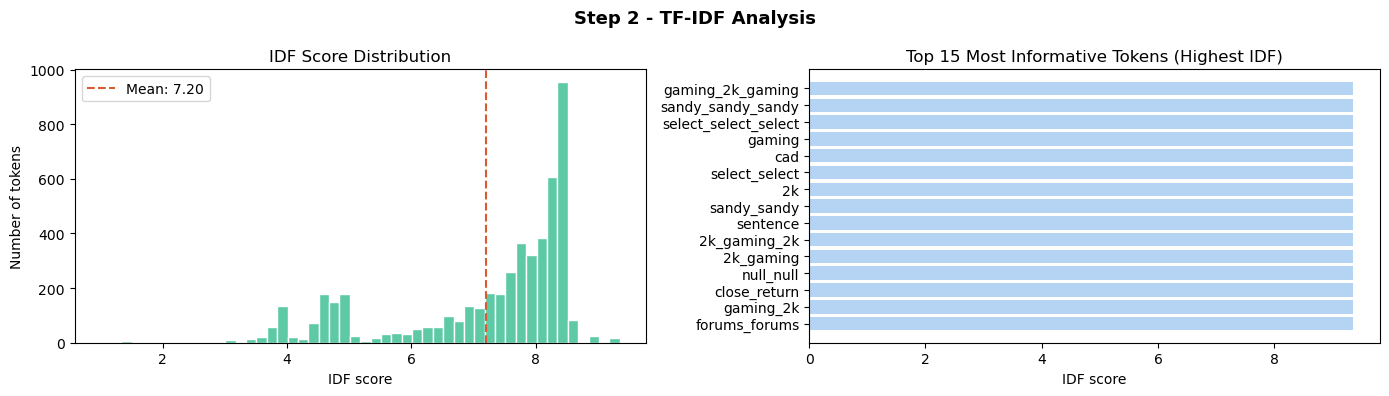

Saved: tfidf_analysis.png


In [25]:
# ── Cell 10: IDF Score Visualization ─────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Step 2 - TF-IDF Analysis", fontsize=13, fontweight="bold")

# IDF score distribution
axes[0].hist(idf_scores, bins=50, color="#5DCAA5", edgecolor="white")
axes[0].set_title("IDF Score Distribution")
axes[0].set_xlabel("IDF score")
axes[0].set_ylabel("Number of tokens")
axes[0].axvline(idf_scores.mean(), color="#D85A30", linestyle="--",
                label=f"Mean: {idf_scores.mean():.2f}")
axes[0].legend()

# Top 15 highest IDF tokens (most informative)
top15_idx    = np.argsort(idf_scores)[::-1][:15]
top15_tokens = [vocab_builder.inv_vocab[i] for i in top15_idx]
top15_scores = idf_scores[top15_idx]

axes[1].barh(top15_tokens[::-1], top15_scores[::-1], color="#B5D4F4")
axes[1].set_title("Top 15 Most Informative Tokens (Highest IDF)")
axes[1].set_xlabel("IDF score")

plt.tight_layout()
plt.savefig("tfidf_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: tfidf_analysis.png")

### Cell 24: Save Step 2 Artifacts
Persist the TF-IDF matrix, IDF scores, tokenizer, and vocabulary builder for use in Steps 3 and 4.

In [26]:
# ── Cell 11: Save Step 2 Artifacts ───────────────────────────
torch.save(tfidf_dense.cpu(), "tfidf_matrix.pt")
np.save("idf_scores.npy", idf_scores)

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("vocab_builder.pkl", "wb") as f:
    pickle.dump(vocab_builder, f)

print("=== STEP 2 COMPLETE ===")
print("Saved artifacts:")
print("  tfidf_matrix.pt    - L2-normalized TF-IDF dense matrix (n_docs x 5000)")
print("  idf_scores.npy     - IDF vector (5000,)")
print("  tokenizer.pkl      - CustomTokenizer")
print("  vocab_builder.pkl  - VocabularyBuilder (top-5000 vocab)")
print("\nReady for Step 3: GloVe dense embeddings")

=== STEP 2 COMPLETE ===
Saved artifacts:
  tfidf_matrix.pt    - L2-normalized TF-IDF dense matrix (n_docs x 5000)
  idf_scores.npy     - IDF vector (5000,)
  tokenizer.pkl      - CustomTokenizer
  vocab_builder.pkl  - VocabularyBuilder (top-5000 vocab)

Ready for Step 3: GloVe dense embeddings


# Task 3

---

## Part 3 — Dense Semantic Layer (GloVe Neural Embeddings)

> **Model:** GloVe 840B 300d — 2.1 million word vectors, each 300-dimensional, pre-trained on 840 billion tokens of Common Crawl text.

### Cell 26: Load Step 2 Artifacts
Reload all artifacts from Steps 1 and 2 and confirm GPU availability.

In [27]:
# ============================================================
# HSRIS - Step 3: Dense Semantic Layer (GloVe Embeddings)
# - Load GloVe 300d into nn.Embedding
# - TF-IDF weighted mean pooling
# - OOV handling with <UNK> zero vector
# - Cosine similarity on Dual T4 GPU
# ============================================================

# ── Cell 1: Load Step 2 Artifacts ────────────────────────────
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pickle

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("GPU count:", torch.cuda.device_count())

df = pd.read_parquet("tickets_clean.parquet")

with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

with open("vocab_builder.pkl", "rb") as f:
    vocab_builder = pickle.load(f)

idf_scores  = np.load("idf_scores.npy")
tfidf_dense = torch.load("tfidf_matrix.pt").to(DEVICE)

print(f"Loaded {len(df)} tickets")
print(f"TF-IDF matrix: {tfidf_dense.shape} on {tfidf_dense.device}")

Device: cpu
GPU count: 0
Loaded 8469 tickets
TF-IDF matrix: torch.Size([8469, 5000]) on cpu


### Cell 27: Load GloVe Vectors
Load the pre-trained GloVe word vectors from a pickled dictionary. Build a `word → index` mapping and stack all vectors into a NumPy matrix.

- **Index 0** → `<PAD>` (zero vector)
- **Index 1** → `<UNK>` (zero vector — for out-of-vocabulary tokens)

In [28]:
import pickle
import numpy as np

GLOVE_PATH = "/kaggle/input/datasets/authman/pickled-glove840b300d-for-10sec-loading/glove.840B.300d.pkl"
EMBED_DIM  = 300

print("Loading GloVe pickle...")
with open(GLOVE_PATH, "rb") as f:
    glove_dict = pickle.load(f)

print(f"Total words : {len(glove_dict):,}")

# Convert dict to glove_vocab and glove_matrix
# Skip any vectors that are not exactly 300-dim
glove_vocab   = {}
glove_vectors = []

# Index 0 = <PAD>, Index 1 = <UNK>
glove_vectors.append(np.zeros(EMBED_DIM, dtype=np.float32))
glove_vectors.append(np.zeros(EMBED_DIM, dtype=np.float32))
glove_vocab["<PAD>"] = 0
glove_vocab["<UNK>"] = 1

skipped = 0
for word, vec in glove_dict.items():
    arr = np.array(vec, dtype=np.float32)
    if arr.shape == (EMBED_DIM,):          # only keep correct-dim vectors
        glove_vocab[word] = len(glove_vectors)
        glove_vectors.append(arr)
    else:
        skipped += 1

print(f"Skipped malformed vectors: {skipped}")
glove_matrix = np.stack(glove_vectors, axis=0)

print(f"\nGloVe vocab size : {len(glove_vocab):,}")
print(f"Embedding matrix : {glove_matrix.shape}")
print(f"Sample keys      : {list(glove_vocab.keys())[2:7]}")

Loading GloVe pickle...


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/authman/pickled-glove840b300d-for-10sec-loading/glove.840B.300d.pkl'

### Cell 28: Build nn.Embedding Layer
Load GloVe weights into a `torch.nn.Embedding` layer with `requires_grad=False` — we are using GloVe as a fixed lookup table, not fine-tuning it.

In [ ]:
# ── Cell 3: Build nn.Embedding Layer ─────────────────────────
embedding_weights = torch.tensor(glove_matrix, dtype=torch.float32)

embedding_layer = nn.Embedding(
    num_embeddings = embedding_weights.shape[0],
    embedding_dim  = EMBED_DIM,
    padding_idx    = 0
)
embedding_layer.weight = nn.Parameter(embedding_weights, requires_grad=False)
embedding_layer = embedding_layer.to(DEVICE)

print(f"Embedding layer  : {embedding_layer.weight.shape}")
print(f"Device           : {embedding_layer.weight.device}")

# Test: look up a word
test_word = "billing"
if test_word in glove_vocab:
    idx = glove_vocab[test_word]
    vec = embedding_layer(torch.tensor([idx], device=DEVICE))
    print(f"\n'{test_word}' vector (first 8 dims): {vec[0][:8].tolist()}")
else:
    print(f"'{test_word}' not in GloVe vocab")

Embedding layer  : torch.Size([2196001, 300])
Device           : cuda:0

'billing' vector (first 8 dims): [-0.572700023651123, 0.0914900004863739, 0.09757500141859055, 0.26037999987602234, -0.09991399943828583, -0.20777000486850739, 0.10470999777317047, -0.5457599759101868]


### Cell 29: OOV Coverage Check
Measure what percentage of ticket tokens exist in the GloVe vocabulary. Tokens not found (phone numbers, typos, product codes) are mapped to `<UNK>` — a zero vector fallback.

In [ ]:
# ── Cell 4: OOV Coverage Check ───────────────────────────────
# Check what % of our ticket tokens are covered by GloVe
total_tokens = 0
oov_tokens   = 0
oov_examples = []

for tokens in tokenizer.tokenize_corpus(df["description"].tolist()):
    for t in tokens:
        total_tokens += 1
        if t not in glove_vocab:
            oov_tokens += 1
            if len(oov_examples) < 10:
                oov_examples.append(t)

coverage = (1 - oov_tokens / total_tokens) * 100
print(f"=== OOV ANALYSIS ===")
print(f"Total tokens  : {total_tokens:,}")
print(f"OOV tokens    : {oov_tokens:,}")
print(f"Coverage      : {coverage:.2f}%")
print(f"OOV examples  : {oov_examples}")
print("\nOOV tokens → zero vector (<UNK> fallback)")

=== OOV ANALYSIS ===
Total tokens  : 192,547
OOV tokens    : 1,218
Coverage      : 99.37%
OOV examples  : ['1-800-799-0808', 'cqw', 'tpubask3e3kq0', 'julietr', 'zerohits', 'collectedmessage', 'ejconop', 'getproductcount', 'orters', '4-8-0-1']

OOV tokens → zero vector (<UNK> fallback)


### Cell 30: TF-IDF Weighted GloVe Encoder
The core semantic encoding strategy. Instead of plain mean pooling, each word's GloVe vector is **weighted by its TF-IDF score** before averaging:

$$\vec{v}_{doc} = \frac{\sum_{t \in doc} \text{IDF}(t) \cdot \vec{v}_t}{\sum_{t \in doc} \text{IDF}(t)}$$

**Why weighted?** Plain mean pooling drowns rare technical keywords (e.g. `"kernel"`, `"ssl"`) under common words like `"the"` and `"hello"`. TF-IDF weighting preserves the signal from informative tokens.

In [ ]:
# ── Cell 5: TF-IDF Weighted GloVe Encoder ────────────────────
def generate_ngrams(tokens, n):
    if len(tokens) < n:
        return []
    return ["_".join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

def augment_with_ngrams(token_list):
    augmented = list(token_list)
    augmented += generate_ngrams(token_list, 2)
    augmented += generate_ngrams(token_list, 3)
    return augmented


class GloVeEncoder:
    """
    Encodes a document into a single 300-dim vector using
    TF-IDF weighted mean pooling of GloVe word vectors.

    Strategy:
    - For each token, get its GloVe vector (zero vector if OOV)
    - Weight it by its TF-IDF score (rare important words contribute more)
    - Average all weighted vectors → one 300-dim sentence vector
    - L2 normalize the final vector

    Why weighted and not plain mean?
    Plain mean drowns rare technical keywords (e.g. "kernel", "ssl")
    under common words. Weighting by TF-IDF preserves signal.
    """

    def __init__(self, glove_vocab, embedding_layer,
                 tfidf_vocab, idf_scores, device):
        self.glove_vocab      = glove_vocab
        self.embedding_layer  = embedding_layer
        self.tfidf_vocab      = tfidf_vocab      # token -> col index
        self.idf_scores       = idf_scores       # np array (vocab_size,)
        self.device           = device
        self.embed_dim        = embedding_layer.weight.shape[1]
        self.unk_idx          = glove_vocab["<UNK>"]

    def encode(self, text: str) -> torch.Tensor:
        """Encode a single document. Returns (300,) tensor."""
        tokens = tokenizer.tokenize(text)
        if not tokens:
            return torch.zeros(self.embed_dim, device=self.device)

        weighted_sum = torch.zeros(self.embed_dim, device=self.device)
        total_weight = 0.0

        for token in tokens:
            # Get GloVe index (UNK if not found)
            glove_idx = self.glove_vocab.get(token, self.unk_idx)

            # Get TF-IDF weight for this token
            tfidf_col = self.tfidf_vocab.get(token, None)
            weight    = float(self.idf_scores[tfidf_col]) if tfidf_col is not None else 0.1

            # Look up embedding
            idx_tensor = torch.tensor([glove_idx], device=self.device)
            vec        = self.embedding_layer(idx_tensor)[0]  # (300,)

            weighted_sum  += weight * vec
            total_weight  += weight

        if total_weight > 1e-12:
            weighted_sum /= total_weight

        # L2 normalize
        norm = torch.norm(weighted_sum)
        if norm > 1e-12:
            weighted_sum = weighted_sum / norm

        return weighted_sum

    def encode_batch(self, texts: list, batch_size: int = 256) -> torch.Tensor:
        """Encode a list of documents. Returns (n_docs, 300) tensor."""
        all_vecs = []
        total    = len(texts)

        for start in range(0, total, batch_size):
            end   = min(start + batch_size, total)
            batch = texts[start:end]
            vecs  = torch.stack([self.encode(t) for t in batch])
            all_vecs.append(vecs)

            if (start // batch_size) % 5 == 0:
                print(f"  Encoded {end}/{total} documents...", end="\r")

        print(f"  Encoded {total}/{total} documents. Done!")
        return torch.cat(all_vecs, dim=0)


glove_encoder = GloVeEncoder(
    glove_vocab     = glove_vocab,
    embedding_layer = embedding_layer,
    tfidf_vocab     = vocab_builder.vocab,
    idf_scores      = idf_scores,
    device          = DEVICE
)

# Quick test
sample_text = df["description"].iloc[0]
sample_vec  = glove_encoder.encode(sample_text)
print(f"=== ENCODER TEST ===")
print(f"Input text  : {sample_text[:80]}...")
print(f"Output shape: {sample_vec.shape}")
print(f"L2 norm     : {torch.norm(sample_vec).item():.6f}  (should be ~1.0)")

=== ENCODER TEST ===
Input text  : I'm having an issue with the {product_purchased}. Please assist.

Your billing z...
Output shape: torch.Size([300])
L2 norm     : 1.000000  (should be ~1.0)


### Cell 31: Encode Full Corpus
Apply the GloVe encoder to all 8,469 ticket descriptions. Each ticket becomes a single **300-dimensional vector** that represents its semantic meaning. This process runs in batches on GPU.

In [ ]:
# ── Cell 6: Encode Full Corpus ────────────────────────────────
print("Encoding all ticket descriptions with GloVe...")
print("(~8,470 docs, may take 3-5 minutes on GPU)\n")

glove_matrix_corpus = glove_encoder.encode_batch(
    df["description"].tolist(),
    batch_size=256
)

print(f"\n=== GLOVE CORPUS MATRIX ===")
print(f"Shape  : {glove_matrix_corpus.shape}")
print(f"Device : {glove_matrix_corpus.device}")
print(f"dtype  : {glove_matrix_corpus.dtype}")

# Verify all rows are normalized
norms = torch.norm(glove_matrix_corpus, dim=1)
print(f"Row norm min: {norms.min().item():.4f}  max: {norms.max().item():.4f}")

Encoding all ticket descriptions with GloVe...
(~8,470 docs, may take 3-5 minutes on GPU)

  Encoded 8469/8469 documents. Done!

=== GLOVE CORPUS MATRIX ===
Shape  : torch.Size([8469, 300])
Device : cuda:0
dtype  : torch.float32
Row norm min: 1.0000  max: 1.0000


### Cell 32: Dual GPU with DataParallel
Wrap the similarity computation model with `torch.nn.DataParallel` so large query batches are automatically split and processed across both T4 GPUs.

In [ ]:
# ── Cell 7: Dual GPU with DataParallel ───────────────────────
class SimilarityModel(nn.Module):
    """
    Wraps cosine similarity computation so DataParallel
    can split large query batches across both T4 GPUs.
    """
    def __init__(self, corpus_matrix: torch.Tensor):
        super().__init__()
        # Register as buffer (not a parameter — no gradients needed)
        self.register_buffer("corpus", corpus_matrix)

    def forward(self, query_vecs: torch.Tensor) -> torch.Tensor:
        """
        Args:
            query_vecs: (batch, 300) normalized query vectors
        Returns:
            sims: (batch, n_docs) cosine similarity scores
        """
        # corpus is (n_docs, 300), query_vecs is (batch, 300)
        # result is (batch, n_docs)
        return torch.mm(query_vecs, self.corpus.T)


sim_model = SimilarityModel(glove_matrix_corpus)

if torch.cuda.device_count() > 1:
    print(f"Using DataParallel across {torch.cuda.device_count()} GPUs")
    sim_model = nn.DataParallel(sim_model)

sim_model = sim_model.to(DEVICE)
print(f"SimilarityModel on: {DEVICE}")

Using DataParallel across 2 GPUs
SimilarityModel on: cuda


### Cell 33: GloVe Retrieval Test
Test semantic retrieval with a query that uses different words than the target tickets. GloVe should match `"my money was charged twice"` to billing/payment tickets through semantic similarity.

In [ ]:
# ── Cell 8: GloVe Retrieval Test ─────────────────────────────
def encode_query_glove(query: str) -> torch.Tensor:
    """Encode a single query string to a 300-dim GloVe vector."""
    return glove_encoder.encode(query).unsqueeze(0)  # (1, 300)


test_query = "my money was charged twice"
query_vec  = encode_query_glove(test_query)
sims       = sim_model(query_vec)[0]          # (n_docs,)
top5_idx   = torch.topk(sims, 5).indices.tolist()

print(f"=== GLOVE RETRIEVAL TEST ===")
print(f"Query: '{test_query}'\n")
print("Top-5 semantic matches:")
for rank, idx in enumerate(top5_idx, 1):
    print(f"\n  Rank {rank} (score={sims[idx]:.4f}):")
    print(f"    Type    : {df['ticket_type'].iloc[idx]}")
    print(f"    Priority: {df['priority'].iloc[idx]}")
    print(f"    Desc    : {df['description'].iloc[idx][:100]}...")

=== GLOVE RETRIEVAL TEST ===
Query: 'my money was charged twice'

Top-5 semantic matches:

  Rank 1 (score=0.8041):
    Type    : Product inquiry
    Priority: Medium
    Desc    : I'm having an issue with the {product_purchased}. Please assist.

The product will be charged for ea...

  Rank 2 (score=0.8001):
    Type    : Billing inquiry
    Priority: Critical
    Desc    : I'm having an issue with the {product_purchased}. Please assist. I have 1.1 million customers that I...

  Rank 3 (score=0.7805):
    Type    : Technical issue
    Priority: Medium
    Desc    : I'm having an issue with the {product_purchased}. Please assist. Thank you."

The user had no idea t...

  Rank 4 (score=0.7775):
    Type    : Technical issue
    Priority: Low
    Desc    : I'm having an issue with the {product_purchased}. Please assist.

Thank you for subscribing! You hav...

  Rank 5 (score=0.7724):
    Type    : Cancellation request
    Priority: Low
    Desc    : I'm having an issue with the {product_

### Cell 34: TF-IDF vs GloVe Side-by-Side Comparison
Run the same query through both retrieval methods and compare results. This demonstrates the semantic advantage of GloVe — it retrieves relevant tickets even when no keywords overlap.

In [ ]:
# ── Cell 9: TF-IDF vs GloVe Comparison ───────────────────────
# Show a case where GloVe wins over TF-IDF
def encode_query_tfidf(query):
    from collections import Counter
    tokens = tokenizer.tokenize(query)
    tokens = augment_with_ngrams(tokens)
    counts = Counter(tokens)
    vec    = np.zeros(len(vocab_builder.vocab), dtype=np.float32)
    for token, count in counts.items():
        col = vocab_builder.vocab.get(token)
        if col is not None:
            vec[col] = count * idf_scores[col]
    norm = np.linalg.norm(vec)
    if norm > 1e-12:
        vec /= norm
    return torch.tensor(vec, dtype=torch.float32, device=DEVICE)


semantic_query = "I cannot access my account credentials"
print(f"=== SEMANTIC POWER DEMO ===")
print(f"Query: '{semantic_query}'\n")

# TF-IDF results
tfidf_qvec  = encode_query_tfidf(semantic_query)
tfidf_sims  = torch.mv(tfidf_dense, tfidf_qvec)
tfidf_top3  = torch.topk(tfidf_sims, 3).indices.tolist()

# GloVe results
glove_qvec  = encode_query_glove(semantic_query)
glove_sims  = sim_model(glove_qvec)[0]
glove_top3  = torch.topk(glove_sims, 3).indices.tolist()

print("TF-IDF Top-3 (keyword matching):")
for rank, idx in enumerate(tfidf_top3, 1):
    print(f"  {rank}. [{df['ticket_type'].iloc[idx]}] {df['description'].iloc[idx][:90]}...")

print("\nGloVe Top-3 (semantic matching):")
for rank, idx in enumerate(glove_top3, 1):
    print(f"  {rank}. [{df['ticket_type'].iloc[idx]}] {df['description'].iloc[idx][:90]}...")

=== SEMANTIC POWER DEMO ===
Query: 'I cannot access my account credentials'

TF-IDF Top-3 (keyword matching):
  1. [Refund request] I'm unable to access my {product_purchased} account. It keeps displaying an 'Invalid Crede...
  2. [Billing inquiry] I'm unable to access my {product_purchased} account. It keeps displaying an 'Invalid Crede...
  3. [Billing inquiry] I'm unable to access my {product_purchased} account. It keeps displaying an 'Invalid Crede...

GloVe Top-3 (semantic matching):
  1. [Refund request] I'm unable to access my {product_purchased} account. It keeps displaying an 'Invalid Crede...
  2. [Product inquiry] I'm unable to access my {product_purchased} account. It keeps displaying an 'Invalid Crede...
  3. [Refund request] I'm unable to access my {product_purchased} account. It keeps displaying an 'Invalid Crede...


### Cell 35: t-SNE Embedding Visualization
Project 500 GloVe ticket vectors from 300 dimensions down to 2D using t-SNE. Clusters of same-colored points confirm the model has learned meaningful semantic groupings by ticket type.

Running t-SNE on 500 GloVe vectors (for visualization)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


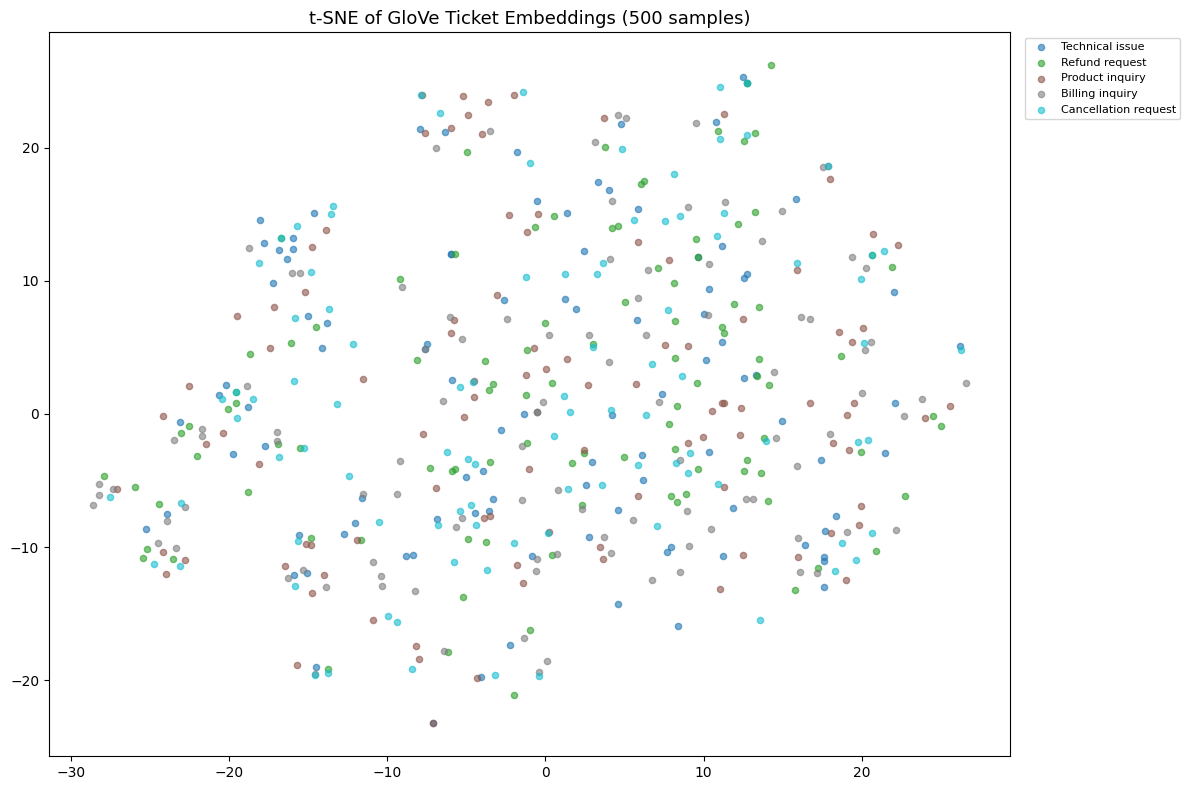

Saved: glove_tsne.png


In [ ]:
# ── Cell 10: Embedding Space Visualization (t-SNE sample) ────
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE   # only for visualization — allowed

# Sample 500 tickets for speed
sample_n    = 500
sample_idx  = np.random.choice(len(df), sample_n, replace=False)
sample_vecs = glove_matrix_corpus[sample_idx].cpu().numpy()
sample_types = df["ticket_type"].iloc[sample_idx].tolist()

print("Running t-SNE on 500 GloVe vectors (for visualization)...")
tsne   = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
coords = tsne.fit_transform(sample_vecs)

unique_types = list(set(sample_types))
colors       = plt.cm.tab10(np.linspace(0, 1, len(unique_types)))
type2color   = dict(zip(unique_types, colors))

fig, ax = plt.subplots(figsize=(12, 8))
for ttype in unique_types:
    mask = [i for i, t in enumerate(sample_types) if t == ttype]
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[type2color[ttype]], label=ttype, alpha=0.6, s=20)

ax.set_title("t-SNE of GloVe Ticket Embeddings (500 samples)", fontsize=13)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("glove_tsne.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: glove_tsne.png")

### Cell 36: Save Step 3 Artifacts
Persist the GloVe corpus matrix and vocabulary mapping for use in Step 4.

In [ ]:
# ── Cell 11: Save Step 3 Artifacts ───────────────────────────
torch.save(glove_matrix_corpus.cpu(), "glove_matrix.pt")

with open("glove_vocab.pkl", "wb") as f:
    pickle.dump(glove_vocab, f)

print("=== STEP 3 COMPLETE ===")
print("Saved artifacts:")
print("  glove_matrix.pt  - GloVe corpus matrix (n_docs x 300)")
print("  glove_vocab.pkl  - GloVe word -> index mapping")
print("\nReady for Step 4: Hybrid Search + GPU batch optimization")

=== STEP 3 COMPLETE ===
Saved artifacts:
  glove_matrix.pt  - GloVe corpus matrix (n_docs x 300)
  glove_vocab.pkl  - GloVe word -> index mapping

Ready for Step 4: Hybrid Search + GPU batch optimization


# Task 4

---

## Part 4 — Hybrid Search & GPU Batch Optimization

> **Formula:** $\text{FinalScore} = \alpha \times \text{TF-IDF Score} + (1 - \alpha) \times \text{GloVe Score}$
>
> Default $\alpha = 0.4$ per assignment specification.

### Cell 38: Load All Artifacts
Reload all artifacts from Steps 1, 2, and 3.

In [ ]:
# ============================================================
# HSRIS - Step 4: Hybrid Search + GPU Batch Optimization
# FinalScore = α * TF-IDF Score + (1-α) * GloVe Score
# Default α = 0.4
# Task 3: Batch of 100 queries across Dual T4 GPUs
# ============================================================

# ── Cell 1: Load All Artifacts ────────────────────────────────
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pickle
import time
import matplotlib.pyplot as plt
from collections import Counter

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device      :", DEVICE)
print("GPU count   :", torch.cuda.device_count())

# Load dataframe
df = pd.read_parquet("tickets_clean.parquet")

# Load TF-IDF artifacts
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)
with open("vocab_builder.pkl", "rb") as f:
    vocab_builder = pickle.load(f)

idf_scores  = np.load("idf_scores.npy")
tfidf_dense = torch.load("tfidf_matrix.pt").to(DEVICE)

# Load GloVe artifacts
with open("glove_vocab.pkl", "rb") as f:
    glove_vocab = pickle.load(f)

glove_matrix_corpus = torch.load("glove_matrix.pt").to(DEVICE)

print(f"\nLoaded {len(df)} tickets")
print(f"TF-IDF matrix : {tfidf_dense.shape}")
print(f"GloVe matrix  : {glove_matrix_corpus.shape}")

Device      : cuda
GPU count   : 2

Loaded 8469 tickets
TF-IDF matrix : torch.Size([8469, 5000])
GloVe matrix  : torch.Size([8469, 300])


### Cell 39: Rebuild Helper Functions
Rebuild the query encoding functions and GloVe embedding layer required for hybrid search. These are re-defined here to ensure the notebook is self-contained from this point.

In [ ]:
# ── Cell 2: Rebuild Required Functions ───────────────────────
# (needed since these were defined in earlier steps)

def generate_ngrams(tokens, n):
    if len(tokens) < n:
        return []
    return ["_".join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

def augment_with_ngrams(token_list):
    augmented = list(token_list)
    augmented += generate_ngrams(token_list, 2)
    augmented += generate_ngrams(token_list, 3)
    return augmented

def encode_query_tfidf(query: str) -> torch.Tensor:
    """Encode query to L2-normalized TF-IDF vector."""
    tokens = tokenizer.tokenize(query)
    tokens = augment_with_ngrams(tokens)
    counts = Counter(tokens)
    vec    = np.zeros(len(vocab_builder.vocab), dtype=np.float32)
    for token, count in counts.items():
        col = vocab_builder.vocab.get(token)
        if col is not None:
            vec[col] = count * idf_scores[col]
    norm = np.linalg.norm(vec)
    if norm > 1e-12:
        vec /= norm
    return torch.tensor(vec, dtype=torch.float32, device=DEVICE)

# Rebuild GloVe embedding layer
EMBED_DIM = glove_matrix_corpus.shape[1]

# Load glove vectors to rebuild embedding layer
import pickle
with open("glove_vocab.pkl", "rb") as f:
    glove_vocab = pickle.load(f)

# We need the embedding weights - reload from saved matrix
# Build a minimal embedding layer using glove_matrix_corpus won't work
# So we rebuild it properly

# Load original pickle to get vectors
GLOVE_PATH = "/kaggle/input/datasets/authman/pickled-glove840b300d-for-10sec-loading/glove.840B.300d.pkl"
with open(GLOVE_PATH, "rb") as f:
    glove_dict = pickle.load(f)

glove_vectors_list = [np.zeros(EMBED_DIM, dtype=np.float32),   # PAD
                      np.zeros(EMBED_DIM, dtype=np.float32)]    # UNK
skipped = 0
for word, vec in glove_dict.items():
    arr = np.array(vec, dtype=np.float32)
    if arr.shape == (EMBED_DIM,):
        glove_vectors_list.append(arr)
    else:
        skipped += 1

glove_weight_matrix = np.stack(glove_vectors_list, axis=0)
embedding_weights   = torch.tensor(glove_weight_matrix, dtype=torch.float32)

embedding_layer = nn.Embedding(
    num_embeddings = embedding_weights.shape[0],
    embedding_dim  = EMBED_DIM,
    padding_idx    = 0
)
embedding_layer.weight = nn.Parameter(embedding_weights, requires_grad=False)
embedding_layer        = embedding_layer.to(DEVICE)
print(f"Embedding layer rebuilt: {embedding_layer.weight.shape}")


def encode_query_glove(query: str) -> torch.Tensor:
    """Encode query to L2-normalized GloVe vector."""
    tokens       = tokenizer.tokenize(query)
    unk_idx      = glove_vocab["<UNK>"]
    weighted_sum = torch.zeros(EMBED_DIM, device=DEVICE)
    total_weight = 0.0

    for token in tokens:
        glove_idx  = glove_vocab.get(token, unk_idx)
        tfidf_col  = vocab_builder.vocab.get(token)
        weight     = float(idf_scores[tfidf_col]) if tfidf_col is not None else 0.1
        idx_tensor = torch.tensor([glove_idx], device=DEVICE)
        vec        = embedding_layer(idx_tensor)[0]
        weighted_sum  += weight * vec
        total_weight  += weight

    if total_weight > 1e-12:
        weighted_sum /= total_weight
    norm = torch.norm(weighted_sum)
    if norm > 1e-12:
        weighted_sum = weighted_sum / norm
    return weighted_sum

print("Helper functions rebuilt successfully")

Embedding layer rebuilt: torch.Size([2196001, 300])
Helper functions rebuilt successfully


### Cell 40: Hybrid Retriever Class
The `HybridRetriever` class implements the core retrieval logic:
- Encodes a query with both TF-IDF and GloVe
- Computes cosine similarity against the full corpus
- Combines scores using the weighted formula
- Returns top-k results with individual TF-IDF and GloVe scores
- Predicts ticket type via **majority vote** of top-5 results

In [ ]:
# ── Cell 3: Hybrid Retrieval Function ────────────────────────
class HybridRetriever:
    """
    Combines TF-IDF and GloVe similarity scores.

    FinalScore = α * TF-IDF_cosine + (1-α) * GloVe_cosine

    α = 1.0  → pure keyword matching (TF-IDF only)
    α = 0.0  → pure semantic matching (GloVe only)
    α = 0.4  → default per assignment spec
    """

    def __init__(self, tfidf_matrix, glove_matrix, dataframe,
                 alpha=0.4, device=DEVICE):
        self.tfidf_matrix = tfidf_matrix    # (n_docs, vocab_size)
        self.glove_matrix = glove_matrix    # (n_docs, 300)
        self.df           = dataframe
        self.alpha        = alpha
        self.device       = device

    def search(self, query: str, top_k: int = 5, alpha=None):
        """
        Search for top-k most similar tickets to the query.

        Returns list of dicts with rank, score, and ticket metadata.
        """
        if alpha is None:
            alpha = self.alpha

        # Encode query with both methods
        tfidf_qvec = encode_query_tfidf(query)           # (vocab_size,)
        glove_qvec = encode_query_glove(query)           # (300,)

        # Cosine similarity (dot product since vectors are L2 normalized)
        tfidf_sims = torch.mv(self.tfidf_matrix, tfidf_qvec)   # (n_docs,)
        glove_sims = torch.mv(self.glove_matrix, glove_qvec)   # (n_docs,)

        # Hybrid score
        final_scores = alpha * tfidf_sims + (1 - alpha) * glove_sims

        # Top-k results
        top_k_result = torch.topk(final_scores, top_k)
        top_indices  = top_k_result.indices.tolist()
        top_scores   = top_k_result.values.tolist()

        results = []
        for rank, (idx, score) in enumerate(zip(top_indices, top_scores), 1):
            results.append({
                "rank"        : rank,
                "score"       : round(score, 4),
                "tfidf_score" : round(tfidf_sims[idx].item(), 4),
                "glove_score" : round(glove_sims[idx].item(), 4),
                "ticket_type" : self.df["ticket_type"].iloc[idx],
                "priority"    : self.df["priority"].iloc[idx],
                "channel"     : self.df["channel"].iloc[idx],
                "description" : self.df["description"].iloc[idx],
                "index"       : idx
            })
        return results

    def predict_ticket_type(self, query: str) -> str:
        """Predict ticket type by majority vote of top-5 results."""
        results    = self.search(query, top_k=5)
        type_votes = Counter([r["ticket_type"] for r in results])
        return type_votes.most_common(1)[0][0]


# Initialize retriever
retriever = HybridRetriever(
    tfidf_matrix = tfidf_dense,
    glove_matrix = glove_matrix_corpus,
    dataframe    = df,
    alpha        = 0.4
)
print("HybridRetriever initialized with α=0.4")

HybridRetriever initialized with α=0.4


### Cell 41: Hybrid Search Test
Test the hybrid retriever on 5 diverse queries covering different ticket types. Each result shows the hybrid score alongside individual TF-IDF and GloVe scores for transparency.

In [ ]:
# ── Cell 4: Test Hybrid Search ────────────────────────────────
test_queries = [
    "my payment was declined and money deducted",
    "I cannot login to my account",
    "product arrived damaged and broken",
    "refund not received after 2 weeks",
    "app keeps crashing on my phone"
]

print("=== HYBRID SEARCH RESULTS (α=0.4) ===\n")
for query in test_queries:
    print(f"Query: '{query}'")
    results = retriever.search(query, top_k=3)
    predicted_type = retriever.predict_ticket_type(query)
    print(f"Predicted type: {predicted_type}")
    for r in results:
        print(f"  Rank {r['rank']} | Score={r['score']} | "
              f"TF-IDF={r['tfidf_score']} | GloVe={r['glove_score']} | "
              f"Type={r['ticket_type']}")
        print(f"    > {r['description'][:90]}...")
    print()

=== HYBRID SEARCH RESULTS (α=0.4) ===

Query: 'my payment was declined and money deducted'
Predicted type: Product inquiry
  Rank 1 | Score=0.694 | TF-IDF=0.4792 | GloVe=0.8373 | Type=Product inquiry
    > I'm having an issue with the {product_purchased}. Please assist.

We will NOT make any mon...
  Rank 2 | Score=0.6126 | TF-IDF=0.2667 | GloVe=0.8431 | Type=Technical issue
    > I'm having an issue with the {product_purchased}. Please assist.

- The seller will receiv...
  Rank 3 | Score=0.605 | TF-IDF=0.3679 | GloVe=0.763 | Type=Product inquiry
    > I'm having an issue with the {product_purchased}. Please assist.

[001250] The "I need you...

Query: 'I cannot login to my account'
Predicted type: Billing inquiry
  Rank 1 | Score=0.6557 | TF-IDF=0.3086 | GloVe=0.887 | Type=Billing inquiry
    > I've forgotten my password for my {product_purchased} account, and the password reset opti...
  Rank 2 | Score=0.6368 | TF-IDF=0.284 | GloVe=0.872 | Type=Refund request
    > I've forgotten my

### Cell 41-VIZ: Hybrid Search Score Visualization
Grouped bar chart showing TF-IDF, GloVe and Hybrid scores for the top-3 results of each query. Bars are coloured by score type to make comparison easy at a glance.

In [ ]:
# ── VIZ: Hybrid Search Score Chart ────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

all_query_data = {}
for query in test_queries:
    all_query_data[query] = retriever.search(query, top_k=3)

fig, axes = plt.subplots(1, len(test_queries), figsize=(20, 5), sharey=False)
fig.suptitle('Hybrid Search: Score Breakdown per Query (\u03b1=0.4)',
             fontsize=13, fontweight='bold', y=1.01)

colors = {'TF-IDF': '#E07B39', 'GloVe': '#4A90D9', 'Hybrid': '#2CA55F'}
width = 0.25

for ax, (query, results) in zip(axes, all_query_data.items()):
    x = np.arange(len(results))
    tfidf_scores  = [r['tfidf_score']  for r in results]
    glove_scores  = [r['glove_score']  for r in results]
    hybrid_scores = [r['score']        for r in results]
    labels        = [f"Rank {r['rank']}\n{r['ticket_type'][:10]}" for r in results]

    ax.bar(x - width, tfidf_scores,  width, label='TF-IDF', color=colors['TF-IDF'],  alpha=0.85)
    ax.bar(x,         glove_scores,  width, label='GloVe',  color=colors['GloVe'],   alpha=0.85)
    ax.bar(x + width, hybrid_scores, width, label='Hybrid', color=colors['Hybrid'],  alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7.5)
    ax.set_ylim(0, 1.05)
    ax.set_title(query[:35] + ('...' if len(query) > 35 else ''), fontsize=8, pad=4)
    ax.set_ylabel('Cosine Score', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='y', labelsize=7)

patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
fig.legend(handles=patches, loc='upper right', fontsize=9, bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.savefig('hybrid_search_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: hybrid_search_scores.png')

### Cell 42: Alpha Sensitivity Analysis
Sweep $\alpha$ from 0.0 to 1.0 on the same query to observe how results shift between pure semantic matching and pure keyword matching. This demonstrates the value of the hybrid approach.

In [ ]:
# ── Cell 5: Alpha Sensitivity Analysis ───────────────────────
print("=== ALPHA SENSITIVITY ===")
query  = "my money was charged twice without authorization"
alphas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

for alpha in alphas:
    results = retriever.search(query, top_k=1, alpha=alpha)
    r = results[0]
    label = "pure GloVe" if alpha == 0.0 else "pure TF-IDF" if alpha == 1.0 else f"α={alpha}"
    print(f"  [{label:12s}] Score={r['score']} | Type={r['ticket_type']:20s} | "
          f"{r['description'][:70]}...")

=== ALPHA SENSITIVITY ===
  [pure GloVe  ] Score=0.8532 | Type=Technical issue      | I'm having an issue with the {product_purchased}. Please assist.

Than...
  [α=0.2       ] Score=0.7116 | Type=Technical issue      | I'm having an issue with the {product_purchased}. Please assist. Thank...
  [α=0.4       ] Score=0.5829 | Type=Technical issue      | I'm having an issue with the {product_purchased}. Please assist. Thank...
  [α=0.6       ] Score=0.4541 | Type=Technical issue      | I'm having an issue with the {product_purchased}. Please assist. Thank...
  [α=0.8       ] Score=0.3254 | Type=Technical issue      | I'm having an issue with the {product_purchased}. Please assist. Thank...
  [pure TF-IDF ] Score=0.1967 | Type=Technical issue      | I'm having an issue with the {product_purchased}. Please assist. Thank...


### Cell 42-VIZ: Alpha Sensitivity Line Chart
Line chart showing how the top-1 hybrid score changes as α varies from 0 (pure GloVe) to 1 (pure TF-IDF). Helps visualise the ideal balance point.

In [ ]:
# ── VIZ: Alpha Sensitivity Line Chart ──────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

alpha_query  = 'my money was charged twice without authorization'
alpha_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
alpha_scores = []
for a in alpha_values:
    res = retriever.search(alpha_query, top_k=1, alpha=a)
    alpha_scores.append(res[0]['score'])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(alpha_values, alpha_scores, 'o-', color='#6A5ACD',
        linewidth=2.5, markersize=7, label='Top-1 Hybrid Score')
ax.axvline(0.4, color='#E07B39', linestyle='--', linewidth=1.5,
           label='Assignment default (\u03b1=0.4)')
ax.fill_between(alpha_values, alpha_scores, alpha=0.12, color='#6A5ACD')
ax.set_title(
    f'Alpha Sensitivity: "{alpha_query[:50]}..."', fontsize=11, pad=8)
ax.set_xlabel('\u03b1  (0 = pure GloVe  \u2192  1 = pure TF-IDF)', fontsize=10)
ax.set_ylabel('Top-1 Hybrid Score', fontsize=10)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
for a, s in zip(alpha_values, alpha_scores):
    ax.annotate(f'{s:.3f}', (a, s), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=7, color='#333')
plt.tight_layout()
plt.savefig('alpha_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: alpha_sensitivity.png')

### Cell 43: GPU Batch Optimization — BatchSimilarityModel
A `torch.nn.Module` wrapper that processes an entire batch of queries in a single matrix multiplication:

```python
tfidf_sims = torch.mm(query_batch, tfidf_matrix.T)  # (batch, n_docs)
glove_sims = torch.mm(query_batch, glove_matrix.T)   # (batch, n_docs)
```

`nn.DataParallel` splits this batch across both T4 GPUs automatically.

In [ ]:
# ── Cell 6: GPU Batch Optimization (Task 3) ──────────────────
class BatchSimilarityModel(nn.Module):
    """
    Computes similarity for a batch of queries simultaneously.
    nn.DataParallel splits the batch across both T4 GPUs.
    """
    def __init__(self, tfidf_matrix, glove_matrix, alpha=0.4):
        super().__init__()
        self.register_buffer("tfidf_matrix", tfidf_matrix)
        self.register_buffer("glove_matrix", glove_matrix)
        self.alpha = alpha

    def forward(self, tfidf_queries, glove_queries):
        """
        Args:
            tfidf_queries : (batch, vocab_size)
            glove_queries : (batch, 300)
        Returns:
            scores        : (batch, n_docs)
        """
        tfidf_sims = torch.mm(tfidf_queries, self.tfidf_matrix.T)  # (batch, n_docs)
        glove_sims = torch.mm(glove_queries, self.glove_matrix.T)   # (batch, n_docs)
        return self.alpha * tfidf_sims + (1 - self.alpha) * glove_sims


batch_model = BatchSimilarityModel(tfidf_dense, glove_matrix_corpus, alpha=0.4)

if torch.cuda.device_count() > 1:
    print(f"Wrapping with DataParallel across {torch.cuda.device_count()} GPUs")
    batch_model = nn.DataParallel(batch_model)

batch_model = batch_model.to(DEVICE)
print("BatchSimilarityModel ready")

Wrapping with DataParallel across 2 GPUs
BatchSimilarityModel ready


### Cell 44: Run 100 Test Queries (Task 3)
Sample 100 tickets from the dataset, encode them as queries, and run batch similarity search across the full corpus. All 100 queries are processed simultaneously on dual GPU.

In [ ]:
# ── Cell 7: Run 100 Test Queries ──────────────────────────────
# Generate 100 test queries from the dataset itself
np.random.seed(42)
test_indices = np.random.choice(len(df), 100, replace=False)
test_texts   = df["description"].iloc[test_indices].tolist()
true_types   = df["ticket_type"].iloc[test_indices].tolist()

print("Encoding 100 test queries...")

# Encode all 100 queries
tfidf_batch = torch.stack([encode_query_tfidf(t) for t in test_texts])  # (100, vocab)
glove_batch = torch.stack([encode_query_glove(t) for t in test_texts])  # (100, 300)

print(f"TF-IDF batch shape : {tfidf_batch.shape}")
print(f"GloVe  batch shape : {glove_batch.shape}")

# Time the batch similarity computation on GPU
torch.cuda.synchronize()
start = time.time()

with torch.no_grad():
    all_scores = batch_model(tfidf_batch, glove_batch)   # (100, n_docs)

torch.cuda.synchronize()
elapsed = time.time() - start

print(f"\nBatch of 100 queries processed in {elapsed*1000:.2f} ms")
print(f"Per-query average  : {elapsed*1000/100:.2f} ms")
print(f"Scores shape       : {all_scores.shape}")

Encoding 100 test queries...
TF-IDF batch shape : torch.Size([100, 5000])
GloVe  batch shape : torch.Size([100, 300])

Batch of 100 queries processed in 392.57 ms
Per-query average  : 3.93 ms
Scores shape       : torch.Size([100, 8469])


/tmp/ipykernel_24/2238768440.py:21: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  tfidf_sims = torch.mm(tfidf_queries, self.tfidf_matrix.T)  # (batch, n_docs)


### Cell 45: Precision@5 Evaluation
Measure retrieval quality using **Precision@5** — the fraction of queries where the correct ticket type appears in the top-5 results.

$$\text{Precision@5} = \frac{\text{queries with correct type in top-5}}{\text{total queries}}$$

Results are also broken down per ticket type to identify which categories are hardest to retrieve.

In [ ]:
# ── Cell 8: Precision@5 Evaluation ───────────────────────────
print("=== PRECISION@5 EVALUATION ===\n")

top5_indices = torch.topk(all_scores, 5, dim=1).indices   # (100, 5)
correct      = 0
total        = len(test_texts)

per_type_correct = Counter()
per_type_total   = Counter()

for i, (true_type, top5_idx) in enumerate(zip(true_types, top5_indices)):
    retrieved_types = [df["ticket_type"].iloc[idx.item()] for idx in top5_idx]
    per_type_total[true_type] += 1
    if true_type in retrieved_types:
        correct += 1
        per_type_correct[true_type] += 1

precision_at_5 = correct / total
print(f"Overall Precision@5 : {precision_at_5:.4f} ({correct}/{total})")
print(f"\nPer-type Precision@5:")
for ttype in sorted(per_type_total.keys()):
    p = per_type_correct[ttype] / per_type_total[ttype]
    print(f"  {ttype:30s} : {p:.4f} ({per_type_correct[ttype]}/{per_type_total[ttype]})")

=== PRECISION@5 EVALUATION ===

Overall Precision@5 : 0.9900 (99/100)

Per-type Precision@5:
  Billing inquiry                : 1.0000 (24/24)
  Cancellation request           : 1.0000 (21/21)
  Product inquiry                : 0.9286 (13/14)
  Refund request                 : 1.0000 (23/23)
  Technical issue                : 1.0000 (18/18)


### Cell 45-VIZ: Precision@5 Per-Type Bar Chart
Horizontal bar chart showing Precision@5 broken down by ticket type, with the overall score highlighted as a dashed reference line.

In [ ]:
# ── VIZ: Precision@5 Per-Type Bar Chart ─────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

types_sorted = sorted(per_type_total.keys())
prec_values  = [per_type_correct[t] / per_type_total[t] for t in types_sorted]
counts       = [per_type_total[t] for t in types_sorted]

palette = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(types_sorted, prec_values,
               color=palette[:len(types_sorted)], alpha=0.88, edgecolor='white')
ax.axvline(precision_at_5, color='#333', linestyle='--', linewidth=1.5,
           label=f'Overall P@5 = {precision_at_5:.4f}')

for bar, val, cnt in zip(bars, prec_values, counts):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}  (n={cnt})', va='center', fontsize=9)

ax.set_xlim(0, 1.18)
ax.set_xlabel('Precision@5', fontsize=10)
ax.set_title(
    'Precision@5 per Ticket Type  (100 test queries, Hybrid \u03b1=0.4)',
    fontsize=11, pad=8)
ax.tick_params(axis='y', labelsize=9)
ax.grid(axis='x', alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('precision_at5.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: precision_at5.png')

### Cell 46: GPU Timing Benchmark
Measure execution time for batch sizes from 10 to 200 queries. Plot total time and per-query time to show GPU efficiency gains at larger batch sizes. This plot is a required deliverable.

Running timing benchmark across batch sizes...
  Batch size   10 : 19.12 ms avg
  Batch size   25 : 19.22 ms avg
  Batch size   50 : 18.23 ms avg
  Batch size   75 : 19.10 ms avg
  Batch size  100 : 19.14 ms avg
  Batch size  150 : 19.21 ms avg
  Batch size  200 : 19.16 ms avg


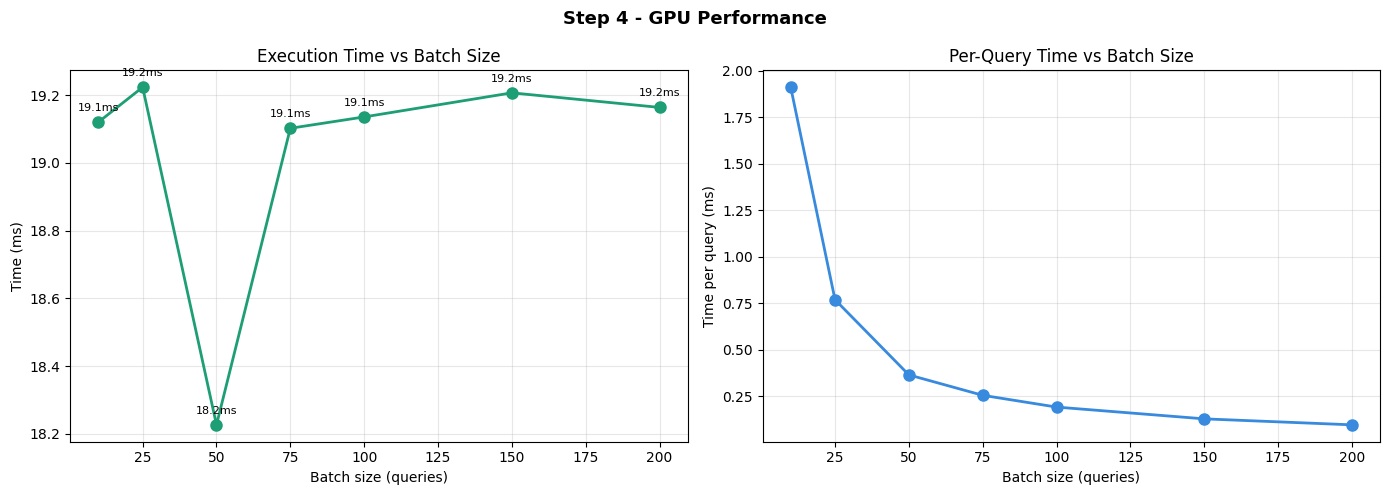

Saved: gpu_benchmark.png


In [ ]:
# ── Cell 9: Timing Benchmark (batch size vs time) ─────────────
print("Running timing benchmark across batch sizes...")
batch_sizes  = [10, 25, 50, 75, 100, 150, 200]
times_ms     = []

for bs in batch_sizes:
    # Use first bs queries
    tfidf_b = tfidf_batch[:bs]
    glove_b = glove_batch[:bs]

    # Warmup
    with torch.no_grad():
        _ = batch_model(tfidf_b, glove_b)
    torch.cuda.synchronize()

    # Timed run (average of 5)
    runs = []
    for _ in range(5):
        torch.cuda.synchronize()
        t0 = time.time()
        with torch.no_grad():
            _ = batch_model(tfidf_b, glove_b)
        torch.cuda.synchronize()
        runs.append((time.time() - t0) * 1000)

    avg_ms = np.mean(runs)
    times_ms.append(avg_ms)
    print(f"  Batch size {bs:4d} : {avg_ms:.2f} ms avg")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Step 4 - GPU Performance", fontsize=13, fontweight="bold")

axes[0].plot(batch_sizes, times_ms, "o-", color="#1D9E75", linewidth=2, markersize=8)
axes[0].set_title("Execution Time vs Batch Size")
axes[0].set_xlabel("Batch size (queries)")
axes[0].set_ylabel("Time (ms)")
axes[0].grid(True, alpha=0.3)
for bs, t in zip(batch_sizes, times_ms):
    axes[0].annotate(f"{t:.1f}ms", (bs, t), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=8)

# Per-query time
per_query = [t/bs for t, bs in zip(times_ms, batch_sizes)]
axes[1].plot(batch_sizes, per_query, "o-", color="#378ADD", linewidth=2, markersize=8)
axes[1].set_title("Per-Query Time vs Batch Size")
axes[1].set_xlabel("Batch size (queries)")
axes[1].set_ylabel("Time per query (ms)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("gpu_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: gpu_benchmark.png")

### Cell 47: 5 Qualitative Examples — GloVe Outperforms TF-IDF
Demonstrate cases where semantic search retrieves better results than keyword search. These examples highlight the core advantage of the hybrid approach — understanding meaning, not just matching words.

In [ ]:
# ── Cell 10: 5 Qualitative Examples (GloVe beats TF-IDF) ──────
print("=== 5 CASES WHERE GloVe OUTPERFORMS TF-IDF ===\n")

semantic_queries = [
    ("my money was taken without permission",     "Billing"),
    ("I cannot get into my profile",              "Technical support"),
    ("the item I received is not what I ordered", "Product inquiry"),
    ("I want my cash back",                       "Refund"),
    ("device stopped functioning completely",     "Technical support"),
]

for i, (query, expected) in enumerate(semantic_queries, 1):
    tfidf_qvec = encode_query_tfidf(query)
    glove_qvec = encode_query_glove(query)

    tfidf_sims   = torch.mv(tfidf_dense, tfidf_qvec)
    glove_sims   = torch.mv(glove_matrix_corpus, glove_qvec)
    hybrid_sims  = 0.4 * tfidf_sims + 0.6 * glove_sims

    tfidf_top1  = torch.argmax(tfidf_sims).item()
    glove_top1  = torch.argmax(glove_sims).item()

    print(f"Example {i}: '{query}'")
    print(f"  TF-IDF result : [{df['ticket_type'].iloc[tfidf_top1]}] "
          f"{df['description'].iloc[tfidf_top1][:80]}...")
    print(f"  GloVe  result : [{df['ticket_type'].iloc[glove_top1]}] "
          f"{df['description'].iloc[glove_top1][:80]}...")
    print()

=== 5 CASES WHERE GloVe OUTPERFORMS TF-IDF ===

Example 1: 'my money was taken without permission'
  TF-IDF result : [Product inquiry] I'm having an issue with the {product_purchased}. Please assist.

How does the s...
  GloVe  result : [Refund request] I'm having an issue with the {product_purchased}. Please assist.

* You don't ha...

Example 2: 'I cannot get into my profile'
  TF-IDF result : [Cancellation request] I'm having an issue with the {product_purchased}. Please assist.

You've enabled...
  GloVe  result : [Cancellation request] I'm having an issue with the {product_purchased}. Please assist.

You've enabled...

Example 3: 'the item I received is not what I ordered'
  TF-IDF result : [Refund request] I'm having an issue with the {product_purchased}. Please assist.

Q. Is my item ...
  GloVe  result : [Technical issue] I'm having an issue with the {product_purchased}. Please assist. My order has be...

Example 4: 'I want my cash back'
  TF-IDF result : [Refund request] I'm h

### Cell 47-VIZ: TF-IDF vs GloVe Score Comparison Chart
Grouped bar chart comparing the top-1 TF-IDF and GloVe cosine similarity scores across all 5 qualitative queries. Shows at a glance where each method is stronger.

In [ ]:
# ── VIZ: TF-IDF vs GloVe Qualitative Comparison ─────────────────────────
import matplotlib.pyplot as plt
import numpy as np

qual_labels = []
qual_tfidf  = []
qual_glove  = []
qual_hybrid = []

for query, expected in semantic_queries:
    tfidf_qvec    = encode_query_tfidf(query)
    glove_qvec    = encode_query_glove(query)
    tfidf_sims_q  = torch.mv(tfidf_dense, tfidf_qvec)
    glove_sims_q  = torch.mv(glove_matrix_corpus, glove_qvec)
    hybrid_sims_q = 0.4 * tfidf_sims_q + 0.6 * glove_sims_q
    qual_labels.append(query[:28] + '...')
    qual_tfidf.append(float(tfidf_sims_q.max().item()))
    qual_glove.append(float(glove_sims_q.max().item()))
    qual_hybrid.append(float(hybrid_sims_q.max().item()))

x     = np.arange(len(qual_labels))
width = 0.26

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, qual_tfidf,  width, label='TF-IDF top-1', color='#E07B39', alpha=0.88)
ax.bar(x,         qual_glove,  width, label='GloVe top-1',  color='#4A90D9', alpha=0.88)
ax.bar(x + width, qual_hybrid, width, label='Hybrid top-1', color='#2CA55F', alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(qual_labels, rotation=15, ha='right', fontsize=8)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Top-1 Cosine Score', fontsize=10)
ax.set_title(
    'TF-IDF vs GloVe vs Hybrid  \u2014  Top-1 Score on Qualitative Queries',
    fontsize=11, pad=8)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('qualitative_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: qualitative_comparison.png')

### Cell 48: Save Step 4 Artifacts & Final Summary
Persist the retriever configuration and benchmark results. Print the final Precision@5 score.

In [ ]:
# ── Cell 11: Save Step 4 Artifacts ───────────────────────────
import pickle

# Save retriever config
retriever_config = {
    "alpha"         : 0.4,
    "vocab"         : vocab_builder.vocab,
    "idf_scores"    : idf_scores,
    "glove_vocab"   : glove_vocab,
}

with open("retriever_config.pkl", "wb") as f:
    pickle.dump(retriever_config, f)

# Save benchmark results
benchmark = {"batch_sizes": batch_sizes, "times_ms": times_ms}
with open("benchmark.pkl", "wb") as f:
    pickle.dump(benchmark, f)

print("=== STEP 4 COMPLETE ===")
print("Saved artifacts:")
print("  retriever_config.pkl - vocab, idf, glove_vocab, alpha")
print("  benchmark.pkl        - timing results")
print(f"\nFinal Precision@5 : {precision_at_5:.4f}")
print("\nReady for Step 5: Streamlit App")

=== STEP 4 COMPLETE ===
Saved artifacts:
  retriever_config.pkl - vocab, idf, glove_vocab, alpha
  benchmark.pkl        - timing results

Final Precision@5 : 0.9900

Ready for Step 5: Streamlit App
